# CONSTRUCCIÓN DATASET

## Fuente datos
“El dataset base proviene de Make Music Equal (licencia CC BY-SA 4.0).
Este fue enriquecido con datos obtenidos mediante la API de Chartmetric, los cuales poseen restricciones de uso. Por este motivo, las variables derivadas de dicha fuente fueron transformadas y agregadas de forma tal que no permiten reconstruir los valores originales.”

PASO 1: Base de artistas para obtener IDs antes de conectar a la API.
Fuente: Make Music Equal (CC BY-SA 4.0)
La base de datos de artistas se descargó del dataset de acceso público MakeMusicEqual versión 3/3/2026: 936420, 10.
https://chartmetric-public.s3.us-west-2.amazonaws.com/make-music-equal/mme_artist_info.csv 
Se eliminaron registros duplicados [nombre + url de artista]: 172
Resultado: 936248 filas/artistas. 
Legal: This work is licensed under a Creative Commons Attribution-ShareAlike 4.0 International License.


PASO 2: Construcción de las cohortes de datos a extraer
Base de datos MakeMusicEqual ordenada por Chartmetric_rank (rank 1 a 936248)
-cohorte 1: 1400 registros 
-cohorte 2: 5600 registros 

Notas:
Hay discontinuidades en el atributo Chartmetric_rank (faltan números en la secuencia) porque la base makemusicequal está actualizada al 3/3/26 aunque fueron descargados el 23/3/2026. Misma fecha de acceso a la API. Como la variable chartmetrick_rank es dinámica, esa diferencia de 20 días hace que un artista pueda tener rank = 5 el 3/3/2026 y rank = 9 el 23/3/26. Sin embargo, eso no invalida la selección del conjunto de artistas sobre la cual se construye la extracción de datos porque el objetivo fue definir un conjunto de artistas ordenados por popularidad (medida por una fuenta de datos confiable). Además la variable rank no será utilizada en el análisis. Y por último, se comprueba que el rank puede variar sutilmente pero el conjunto de artistas definidos es predominantemente coincidente. 

PASO 3: API. Extracción de datos
Free Trial. Límite 14 días, 1000 request x día.
Se apunta a dos endpoints: artist metadata y artist live events
La extracción de datos se fragmenta por cohortes y se resguardan archivos parciales.

PASO 4:
Detectada falta de información en live events > 30%. Se busca mejorar la detección de artistas inactivos, muertos o disueltos dentro del conjunto NA.
Estrategias implementadas: 
1-Musicbrainz (para detectar artistas muertos o bandas desarmadas, has_live_data == False)
2-Wikidata (para detectar artistas muertos o bandas desarmadas, has_live_data == False)
3-Jambase API (acceso a eventos 2022-2023 denegado exclusivo de pago)
4-Chartmetric (acceso a eventos 2022-2023: no existe en la base de datos confirmado por staff)
“Data availability constraints limited historical event retrieval to years 2024-2025”
5-Chartmetric: acceso a shows 2026. Si tienen shows en 2026 no están muertos ni disueltos.

PASO 5: INCREMENTO CANTIDAD FEATURES 
Se recuperó más info del jason:
Band
num_sp_editorial_playlists",
"num_sp_playlists",
"sp_editorial_playlist_total_reach",
"num_am_editorial_playlists",
"num_am_playlists",
"num_de_editorial_playlists",
"num_de_playlists",
"de_playlist_total_reach",
"de_editorial_playlist_total_reach",
"num_az_editorial_playlists",
"num_az_playlists",
"num_yt_editorial_playlists",
"num_yt_playlists",
"yt_playlist_total_reach",
"tiktok_top_video_views",
"tiktok_top_video_comments",
"tiktok_track_posts"


## Justificación recorte 

El conjunto de datos inicial se obtuvo del proyecto Make Music Equal (MME) y contiene aproximadamente 936.000 artistas a nivel mundial. La distribución de los artistas según su etapa de carrera (career stage) presenta una fuerte asimetría: más del 80% se clasifica como undiscovered, mientras que las categorías mid-level, mainstream y superstar representan solo una pequeña fracción de la población total.

Dado que el objetivo de esta investigación es analizar la relación entre las métricas de audiencia digital (plataformas de streaming y redes sociales) y la actividad en presentaciones en vivo, el análisis se concentra en artistas con un nivel de actividad en la industria que pueda medirse de manera consistente.

Para obtener un subconjunto manejable y analíticamente significativo, los artistas fueron ordenados utilizando el Chartmetric Artist Rank, y el dataset se restringió a los 7.000 artistas mejor posicionados.

Este umbral permite capturar el segmento de artistas con presencia relevante de audiencia y actividad en vivo observable, al tiempo que excluye la larga cola de artistas con escasa o nula información pública disponible.

Luego de esta selección, la distribución de las etapas de carrera se desplaza hacia las categorías mid-level, mainstream y superstar, que constituyen la población más pertinente para abordar la pregunta de investigación.

In [54]:
# !pip install pandas numpy matplotlib seaborn scikit-learn jupyter


In [55]:
import pandas as pd
import numpy as np


In [56]:
from pathlib import Path

# ============================================================
# Directorio único de guardado de gráficos y tablas del proyecto
# ============================================================

directorio_salidas_proyecto = Path(
    r"C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\graficos"
)

directorio_salidas_proyecto.mkdir(
    parents=True,
    exist_ok=True
)

print("Directorio de salida:", directorio_salidas_proyecto)
print("Existe:", directorio_salidas_proyecto.exists())


# ejemplo uso
# ruta_grafico_ranking_editorial = (
#     directorio_salidas_proyecto /
#     "ranking_editorial_lifts_top_bottom_trios.png"
# )

# plt.savefig(
#     ruta_grafico_ranking_editorial,
#     dpi=300,
#     bbox_inches="tight"
# )

Directorio de salida: C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\graficos
Existe: True


# levanto dataset

In [57]:
df1 = pd.read_csv("cohorte1_raw_1400.csv") #1400 registros con mas columnas 9-4
df2 = pd.read_csv("cohorte2_raw_5600.csv") # 5600 registros hasta 9-4-26 con más columnas

In [58]:
# ==================================================
# 2) CHEQUEO DE DIMENSIONES
# ==================================================
print("df1 shape:", df1.shape)
print("df2 shape:", df2.shape)

# ==================================================
# 3) CHEQUEO DE COLUMNAS
# ==================================================
cols1 = list(df1.columns)
cols2 = list(df2.columns)

print("Cantidad columnas df:", len(cols1))
print("Cantidad columnas df2:", len(cols2))

solo_en_df1 = sorted(set(cols1) - set(cols2))
solo_en_df2 = sorted(set(cols2) - set(cols1))

print("Columnas solo en df1:", solo_en_df1)
print("Columnas solo en df2:", solo_en_df2)

# ==================================================
# 4) SI LAS COLUMNAS SON LAS MISMAS, ALINEAR ORDEN
# ==================================================
if set(cols1) == set(cols2):
    df2 = df2[df1.columns]
    print("Las columnas coinciden. df2 fue reordenado según df1.")
else:
    raise ValueError("Las columnas no coinciden exactamente entre df1 y df2.")

# ==================================================
# 5) CONCATENAR
# ==================================================
df = pd.concat([df1, df2], ignore_index=True)

print("df concatenado:", df.shape)

# ==================================================
# 6) CONTROLES DE DUPLICADOS
# ==================================================
print("Filas duplicadas exactas:", df.duplicated().sum())

if "chartmetric_id" in df.columns:
    print("Duplicados por chartmetric_id:", df["chartmetric_id"].duplicated().sum())
    
    dup_ids = df.loc[df["chartmetric_id"].duplicated(keep=False), "chartmetric_id"] \
                .sort_values() \
                .unique() \
                .tolist()
    
    print("Cantidad de chartmetric_id duplicados:", len(dup_ids))
    
    if len(dup_ids) > 0:
        print("Primeros ids duplicados:", dup_ids[:20])

# ==================================================
# 7) VISTA RÁPIDA DE NULOS
# ==================================================
print(df.isna().sum().sort_values(ascending=False).head(20))

df1 shape: (1400, 77)
df2 shape: (5600, 77)
Cantidad columnas df: 77
Cantidad columnas df2: 77
Columnas solo en df1: []
Columnas solo en df2: []
Las columnas coinciden. df2 fue reordenado según df1.
df concatenado: (7000, 77)
Filas duplicadas exactas: 0
Duplicados por chartmetric_id: 0
Cantidad de chartmetric_id duplicados: 0
avg_low_price_2024            5002
avg_high_price_2024           5002
n_currencies_2024             4733
main_currency_2024            4733
avg_low_price_2025            4579
avg_high_price_2025           4579
gender_title                  4561
n_currencies_2025             4375
main_currency_2025            4375
total_capacity_2024           4005
n_shows_with_capacity_2024    4005
avg_venue_capacity_2024       4005
n_cities_2024                 3816
shows_per_country_2024        3816
n_countries_2024              3816
n_shows_2024                  3788
avg_venue_capacity_2025       3526
total_capacity_2025           3526
n_shows_with_capacity_2025    3526
n_citie

# concatenamos

In [59]:
df = pd.concat([df1, df2], ignore_index=True)


In [60]:
df.shape

(7000, 77)

# SAVE RAW concatenado

In [61]:
df.to_csv("dataset_raw_concat_7000.csv", index=False)



In [62]:
df.columns

Index(['chartmetric_id', 'artist_name', 'country', 'pronoun_title',
       'gender_title', 'record_label', 'hometown_city', 'cm_artist_rank',
       'cm_artist_score', 'career_stage', 'career_stage_score', 'career_trend',
       'career_trend_score', 'primary_genre', 'sp_followers',
       'sp_monthly_listeners', 'sp_popularity', 'sp_playlist_total_reach',
       'ins_followers', 'twitter_followers', 'tiktok_followers',
       'tiktok_likes', 'ycs_subscribers', 'ycs_views',
       'youtube_daily_video_views', 'youtube_monthly_video_views',
       'deezer_fans', 'shazam_count', 'pandora_lifetime_streams',
       'pandora_lifetime_stations_added', 'band', 'num_sp_editorial_playlists',
       'num_sp_playlists', 'sp_editorial_playlist_total_reach',
       'num_am_editorial_playlists', 'num_am_playlists',
       'num_de_editorial_playlists', 'num_de_playlists',
       'de_playlist_total_reach', 'de_editorial_playlist_total_reach',
       'num_az_editorial_playlists', 'num_az_playlists',
  

In [63]:
df.head()

,chartmetric_id,artist_name,country,pronoun_title,gender_title,record_label,hometown_city,cm_artist_rank,cm_artist_score,career_stage,...,main_currency_2025,shows_per_country_2025,shows_per_country_2024,n_shows_total,n_shows_with_capacity_total,total_capacity_total,avg_venue_capacity_total,n_cities_total,n_countries_total,shows_per_country_total
0,214945,Bad Bunny,PR,he/him,male,Rimas Entertainment,Vega Baja,4,98.976377,superstar,...,USD,9.0,NaN,45.0,44.0,1269124.0,28843.727273,5.0,5.0,9.000000
1,2762,Taylor Swift,US,she/her,female,UMG,Reading,1,99.387117,superstar,...,NaN,NaN,4.9,49.0,49.0,3185238.0,65004.857143,15.0,10.0,4.900000
2,3501,Bruno Mars,US,he/him,male,WMG,Los Angeles,2,99.207939,superstar,...,USD,16.0,6.5,55.0,51.0,1370187.0,26866.411765,11.0,6.0,9.166667
3,3479,Justin Bieber,CA,he/him,male,UMG,Stratford,3,99.079736,superstar,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3852,The Weeknd,CA,he/him,male,UMG,Toronto,7,98.740889,superstar,...,USD,22.0,2.5,49.0,47.0,3080179.0,65535.723404,27.0,4.0,12.250000


# duplicados

In [64]:
# --- 1. CONFIGURACIÓN Y KEY ÚNICA SEGURA ---
# Usamos el ID porque el ID NUNCA es NaN y es la verdad absoluta de Chartmetric
df['unique_entity_key'] = df['chartmetric_id'].astype(str)

# --- 2. ANÁLISIS DE COLISIONES (Nombres iguales, diferentes URL, no son dupli) ---
# Agrupamos por nombre y contamos cuántas URLs distintas existen para ese nombre
analisis = df.groupby('artist_name')['chartmetric_id'].nunique()
colisiones_identidad = analisis[analisis > 1]

# --- 3. IDENTIFICACIÓN DE DUPLICADOS TÉCNICOS ---
# Casos donde la combinación Nombre + URL se repite (deberían ser el mismo registro)
mask_duplicados_tecnicos = df.duplicated(subset=['unique_entity_key'], keep=False)
df_duplicados = df[mask_duplicados_tecnicos].copy()

# Separamos dentro de estos duplicados técnicos:
# A. Filas Espejo: Son copias exactas en todas las columnas
filas_espejo = df_duplicados[df_duplicados.duplicated(keep='first')]

# B. Filas Discrepantes: Mismo artista/URL pero algo cambia en las otras columnas
# Usamos keep=False para marcar todas las filas que tienen conflicto
discrepantes = df_duplicados[~df_duplicados.duplicated(subset=df.columns.difference(['unique_entity_key']), keep=False)]

# --- 4. REPORTE FINAL ---
print("=== INFORME DE CALIDAD DE DATOS ===")
print(f"1. Colisiones de nombre (mismo nombre diferente url): {len(colisiones_identidad)}")
print(f"2. Duplicados Técnicos (Mismo artista + URL): {df.duplicated('unique_entity_key').sum()}")
print(f"   -> Copias exactas (Espejos): {len(filas_espejo)}")
print(f"   -> Registros con datos contradictorios: {len(discrepantes)}")
print("-" * 35)

# Visualización de discrepancias si existen
if not discrepantes.empty:
    print("Muestra de registros con datos discrepantes (mismo artista, distintos valores):")
    print(discrepantes.sort_values(by='unique_entity_key').head(10))

del df["unique_entity_key"]

=== INFORME DE CALIDAD DE DATOS ===
1. Colisiones de nombre (mismo nombre diferente url): 11
2. Duplicados Técnicos (Mismo artista + URL): 0
   -> Copias exactas (Espejos): 0
   -> Registros con datos contradictorios: 0
-----------------------------------


# tipos datos

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 77 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   chartmetric_id                     7000 non-null   int64  
 1   artist_name                        7000 non-null   str    
 2   country                            6933 non-null   str    
 3   pronoun_title                      7000 non-null   str    
 4   gender_title                       2439 non-null   str    
 5   record_label                       6476 non-null   str    
 6   hometown_city                      4392 non-null   str    
 7   cm_artist_rank                     7000 non-null   int64  
 8   cm_artist_score                    7000 non-null   float64
 9   career_stage                       7000 non-null   str    
 10  career_stage_score                 7000 non-null   int64  
 11  career_trend                       7000 non-null   str    
 12  car

# LEVANTO MMEQUAL

In [66]:
df_mmequal = pd.read_csv("mme_artist_info_DATASET.csv")
df_mmequal.shape

C:\Users\Silvana\AppData\Local\Temp\ipykernel_29528\2048803209.py:1: DtypeWarning: Columns (0: chartmetric_rank) have mixed types. Specify dtype option on import or set low_memory=False.
  df_mmequal = pd.read_csv("mme_artist_info_DATASET.csv")


(936420, 10)

In [67]:
df_mmequal.columns

Index(['chartmetric_rank', 'chartmetric_id', 'artist_name', 'chartmetric_url',
       'country_name', 'composition', 'career_stage', 'pronouns', 'genre',
       'data_date'],
      dtype='str')

# comp cm rank discontinuidades

In [71]:
# Asegurar que el ranking sea numérico antes de ordenar
df_mmequal_tmp = df_mmequal.copy()
df_mmequal_tmp["chartmetric_rank_num"] = pd.to_numeric(
    df_mmequal_tmp["chartmetric_rank"],
    errors="coerce"
)

# Top 7000 de df_mmequal según chartmetric_rank ascendente
df_mmequal_top7000 = (
    df_mmequal_tmp
    .dropna(subset=["chartmetric_rank_num"])
    .sort_values("chartmetric_rank_num", ascending=True)
    .head(7000)
    .copy()
)

# Sets de chartmetric_id
ids_df = set(df["chartmetric_id"].dropna())
ids_mmequal_top7000 = set(df_mmequal_top7000["chartmetric_id"].dropna())

# Comparación
ids_coinciden = ids_df.intersection(ids_mmequal_top7000)
ids_solo_en_df = ids_df.difference(ids_mmequal_top7000)
ids_solo_en_mmequal_top7000 = ids_mmequal_top7000.difference(ids_df)

# Resumen
resumen_comparacion = {
    "n_registros_df": len(df),
    "n_ids_unicos_df": len(ids_df),
    "n_registros_mmequal_top7000": len(df_mmequal_top7000),
    "n_ids_unicos_mmequal_top7000": len(ids_mmequal_top7000),
    "n_coincidencias": len(ids_coinciden),
    "n_solo_en_df": len(ids_solo_en_df),
    "n_solo_en_mmequal_top7000": len(ids_solo_en_mmequal_top7000)
}

resumen_comparacion

{'n_registros_df': 7000,
 'n_ids_unicos_df': 7000,
 'n_registros_mmequal_top7000': 7000,
 'n_ids_unicos_mmequal_top7000': 6946,
 'n_coincidencias': 6946,
 'n_solo_en_df': 54,
 'n_solo_en_mmequal_top7000': 0}

In [ ]:
# ============================================================
# Comparar cambio de posición/ranking entre df y df_mmequal_top7000
# Umbral: más de 20 posiciones hacia arriba o hacia abajo
# Solo para IDs presentes en ambos
# ============================================================

df_pos = (
    df[["chartmetric_id", "cm_artist_rank"]]
    .copy()
    .rename(columns={"cm_artist_rank": "rank_df"})
)

df_pos["rank_df"] = pd.to_numeric(df_pos["rank_df"], errors="coerce").astype(float)

df_mmequal_pos = (
    df_mmequal_top7000[["chartmetric_id", "chartmetric_rank_num"]]
    .copy()
    .rename(columns={"chartmetric_rank_num": "rank_mmequal_top7000"})
)

df_mmequal_pos["rank_mmequal_top7000"] = pd.to_numeric(
    df_mmequal_pos["rank_mmequal_top7000"],
    errors="coerce"
).astype(float)

comparacion_ranking_20 = (
    df_pos
    .merge(df_mmequal_pos, on="chartmetric_id", how="inner")
    .dropna(subset=["rank_df", "rank_mmequal_top7000"])
    .copy()
)

comparacion_ranking_20["diferencia_posicion"] = (
    comparacion_ranking_20["rank_df"] - comparacion_ranking_20["rank_mmequal_top7000"]
)

comparacion_ranking_20["cambio_mayor_20_abs"] = (
    comparacion_ranking_20["diferencia_posicion"].abs() > 20
)

comparacion_ranking_20["tipo_cambio"] = "sin cambio > 20"

comparacion_ranking_20.loc[
    comparacion_ranking_20["diferencia_posicion"] > 20,
    "tipo_cambio"
] = "baja más de 20 posiciones en df"

comparacion_ranking_20.loc[
    comparacion_ranking_20["diferencia_posicion"] < -20,
    "tipo_cambio"
] = "sube más de 20 posiciones en df"

resumen_cambios_ranking_20 = (
    comparacion_ranking_20["tipo_cambio"]
    .value_counts()
    .rename_axis("tipo_cambio")
    .reset_index(name="n_ids")
)

display(resumen_cambios_ranking_20)
display(comparacion_ranking_20.head())

,tipo_cambio,n_ids
0,baja más de 20 posiciones en df,4417
1,sube más de 20 posiciones en df,1876
2,sin cambio > 40,707


,chartmetric_id,rank_df,rank_mmequal_top7000,diferencia_posicion,cambio_mayor_20_abs,tipo_cambio
0,214945,4.0,1.0,3.0,False,sin cambio > 40
1,2762,1.0,2.0,-1.0,False,sin cambio > 40
2,3501,2.0,3.0,-1.0,False,sin cambio > 40
3,3479,3.0,4.0,-1.0,False,sin cambio > 40
4,3852,7.0,5.0,2.0,False,sin cambio > 40


# construcción dataset 

In [68]:
import pandas as pd

# 1. Calculamos las estadísticas para el primer DF
stats_df = pd.DataFrame({
    'count_df': df["career_stage"].value_counts(),
    'pct_df': df["career_stage"].value_counts(normalize=True) * 100
})

# 2. Calculamos las estadísticas para el segundo DF (df_mmequal)
stats_mmequal = pd.DataFrame({
    'count_mmequal': df_mmequal["career_stage"].value_counts(),
    'pct_mmequal': df_mmequal["career_stage"].value_counts(normalize=True) * 100
})

# 3. Combinamos ambos resultados en una sola tabla
combined_stats = pd.concat([stats_df, stats_mmequal], axis=1).fillna(0)

# Opcional: Renombrar columnas para que se vea más limpio
combined_stats.columns = ['Count (dataset)', '% (dataset)', 'Count (MMEqual)', '% (MMEqual)']

# Mostrar resultado
print(combined_stats)

              Count (dataset)  % (dataset)  Count (MMEqual)  % (MMEqual)
career_stage                                                            
mainstream             4716.0    67.371429            12828     1.369904
superstar              1886.0    26.942857             1880     0.200765
legendary               376.0     5.371429              369     0.039406
mid-level                14.0     0.200000            18664     1.993131
developing                8.0     0.114286           136101    14.534245
undiscovered              0.0     0.000000           766574    81.862548


In [16]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# # 1. Definir orden
# orden_focalizado = ['undiscovered', 'developing', 'mid-level', 'mainstream', 'superstar', 'legendary']

# def get_clean_stats(df, name):
#     temp_series = df["career_stage"].str.lower().str.strip().str.replace(' ', '-')
#     counts = temp_series.value_counts()
#     total = len(df)
#     stats = counts.reindex(orden_focalizado).fillna(0).reset_index()
#     stats.columns = ['career_stage', 'count']
#     stats['thousands'] = stats['count'] / 1000
#     stats['percentage'] = (stats['count'] / total) * 100
#     return stats

# df1_stats = get_clean_stats(df, 'Original')
# df2_stats = get_clean_stats(df_mmequal, 'MMEqual')

# # 2. Configuración de la figura
# fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(12, 10), sharey=False)

# # Títulos
# plt.suptitle('Construcción dataset 7 mil artistas musicales', fontsize=18, fontweight='bold', y=0.98)
# fig.text(0.5, 0.94, 'Extracción con API. Recorte: Chartmetric rank. Comparación según career_stage', 
#          ha='center', fontsize=12, color='gray', style='italic')

# # Gráfico 1: Dataset Original (Azules)
# sns.barplot(x='career_stage', y='thousands', data=df1_stats, ax=ax1, palette='Blues_r', hue='career_stage', legend=False)
# ax1.set_title('Dataset 7 mil artistas (by rank)', fontsize=14, fontweight='bold', pad=20)
# ax1.set_ylabel('Miles de Artistas (k)', fontsize=12)
# ax1.set_xlabel('')

# # Gráfico 2: Dataset MMEqual (Rojos)
# sns.barplot(x='career_stage', y='thousands', data=df2_stats, ax=ax2, palette='Reds_r', hue='career_stage', legend=False)
# ax2.set_title('1M de artistas', fontsize=14, fontweight='bold', pad=20)
# ax2.set_ylabel('Miles de Artistas (k)', fontsize=12)
# ax2.set_xlabel('')

# # 3. Estética y etiquetas con COLORES DIFERENCIADOS
# for i, (ax, stats_df) in enumerate(zip([ax1, ax2], [df1_stats, df2_stats])):
#     ax.tick_params(axis='x', rotation=30)
#     ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    
#     # Definimos el color del porcentaje según el gráfico (i=0 es ax1/Azul, i=1 es ax2/Rojo)
#     color_pct = 'darkblue' if i == 0 else 'darkred'
    
#     for p, thres, pct in zip(ax.patches, stats_df['thousands'], stats_df['percentage']):
#         val_height = p.get_height()
        
#         if val_height >= 0:
#             k_label = f'{thres:.2f}k' if 0 < thres < 1 else f'{thres:.1f}k'
            
#             # 1. Anotamos la cantidad en NEGRO
#             ax.annotate(k_label, (p.get_x() + p.get_width() / 2., val_height),
#                         ha='center', va='bottom', fontsize=10, fontweight='bold', 
#                         color='black', xytext=(0, 18), textcoords='offset points')
            
#             # 2. Anotamos el porcentaje en el COLOR de la paleta
#             ax.annotate(f'({pct:.1f}%)', (p.get_x() + p.get_width() / 2., val_height),
#                         ha='center', va='bottom', fontsize=10, fontweight='bold', 
#                         color=color_pct, xytext=(0, 6), textcoords='offset points')

# plt.tight_layout(rect=[0, 0.03, 1, 0.92]) 
# plt.show()

In [17]:
#!pip install pandas matplotlib seaborn plotly nbformat nbformat>=4.2.0

In [18]:
# import sys
# !{sys.executable} -m pip install plotly nbformat

In [19]:
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots

# # 1. Definir la figura con títulos de subplots (subplot_titles se encarga de ponerlos arriba)
# fig = make_subplots(
#     rows=1, cols=2, 
#     shared_yaxes=True, 
#     horizontal_spacing=0.07,
#     subplot_titles=("Fuente: 1M artistas", "Dataset 7k artistas") # <--- Títulos arriba
# )

# # Gráfico Izquierda: 1M de artistas (Rojo)
# fig.add_trace(
#     go.Bar(
#         y=labels, x=val2, name='Fuente: 1 millón de artistas',
#         orientation='h',
#         marker=dict(color='rgba(255, 71, 71, 0.7)', line=dict(color='rgba(255, 71, 71, 1.0)', width=2)),
#         customdata=pct2,
#         hovertemplate='<b>%{y}</b><br>Cantidad: %{x}k<br>Porcentaje: %{customdata:.1f}%<extra></extra>',
#         text=[f"{v:.1f}k <br><span style='color:red'>( {p:.1f}% )</span>" for v, p in zip(val2, pct2)],
#         textposition='outside'
#     ), row=1, col=1
# )

# # Gráfico Derecha: Dataset 7k (Azul)
# fig.add_trace(
#     go.Bar(
#         y=labels, x=val1, name='Dataset 7.000 artistas',
#         orientation='h',
#         marker=dict(color='rgba(71, 150, 255, 0.7)', line=dict(color='rgba(71, 150, 255, 1.0)', width=2)),
#         customdata=pct1,
#         hovertemplate='<b>%{y}</b><br>Cantidad: %{x}k<br>Porcentaje: %{customdata:.1f}%<extra></extra>',
#         text=[f"{v:.1f}k <br><span style='color:dodgerblue'>( {p:.1f}% )</span>" for v, p in zip(val1, pct1)],
#         textposition='outside'
#     ), row=1, col=2
# )

# # 2. Configuración estética y ejes
# fig.update_layout(
#     title_text="DATASET ARTISTAS MUSICALES.<br><span style='font-size:13px; color:gray; font-style:italic'>Construcción con API Chartmetric. Recorte: artist rank. <br>Comparación según career_stage</span>",
#     title_x=0.5,
#     template='plotly_dark',
#     showlegend=False,
#     height=750,
#     margin=dict(t=150, b=100, l=100, r=100), # Aumentamos margen superior para los títulos
# )

# # Personalizar ejes X: cuerpo más pequeño (size=10) y color gris (gray)
# fig.update_xaxes(
#     title_text="Miles de artistas", 
#     title_font=dict(size=12, color='gray'), # <--- Aquí ajustas el estilo
#     row=1, col=1, 
#     autorange='reversed'
# )

# fig.update_xaxes(
#     title_text="Miles de artistas", 
#     title_font=dict(size=12, color='gray'), # <--- Lo mismo para el segundo eje
#     row=1, col=2
# )
# # Ajustar tamaño de los títulos de los subplots (arriba)
# fig.update_annotations(font_size=16, font_color="white")

# fig.show()

# # Guarda el gráfico en un archivo local
# fig.write_html("construccion_dataset_bycareerstage.html")

# Feature engineering

## categóricas

 1    country                            6933 non-null   str    
 3   pronoun_title                      7000 non-null   str    
 4   gender_title                       2439 non-null   str    
 5   record_label                       6476 non-null   str    
 6   hometown_city                      4392 non-null   str    
 9   career_stage                       7000 non-null   str    
 11  career_trend                       7000 non-null   str    
 13  primary_genre                      7000 non-null   str    
 30  band                               7000 non-null   bool   
 57  main_currency_2024                 2267 non-null   str    
 67  main_currency_2025                 2625 non-null   str    


In [20]:
cols_cat = [
    "country",
    "pronoun_title",
    "primary_genre",
    "record_label"
]

for col in cols_cat:
    print("\n" + "="*50)
    print(f"Variable: {col}")
    
    # cantidad de niveles
    n_levels = df[col].nunique(dropna=True)
    print(f"Niveles únicos: {n_levels}")
    
    # tabla de frecuencias
    freq = df[col].value_counts(dropna=False)
    prop = df[col].value_counts(normalize=True, dropna=False)
    
    resumen = freq.to_frame(name="count")
    resumen["prop"] = prop
    
    # print(resumen.head(20))  # top 20 niveles


Variable: country
Niveles únicos: 112

Variable: pronoun_title
Niveles únicos: 11

Variable: primary_genre
Niveles únicos: 339

Variable: record_label
Niveles únicos: 3574


## major_record_label
genero booleana a partir de record_label

In [21]:
df["record_label"].value_counts()


record_label
UMG                                                  613
SME                                                  519
WMG                                                  412
BMG Rights Management                                 55
Distrokid                                             37
                                                    ... 
Prod music                                             1
Liam Miller                                            1
XXVI Recordings, a division of XXVI Records, Inc.      1
Aufbau Audio                                           1
Mark Ledlin Records©                                   1
Name: count, Length: 3574, dtype: int64

In [22]:
# Definimos términos clave para buscar variantes
keywords = ['Universal', 'UMG', 'Sony', 'SME', 'Warner', 'WMG', 'BMG']

# Filtramos valores únicos que contengan alguna de esas palabras (ignorando mayúsculas)
variantes_encontradas = df[df['record_label'].str.contains('|'.join(keywords), na=False, case=False)]['record_label'].unique()

print("Variantes detectadas en el dataset:")
print(variantes_encontradas)

Variantes detectadas en el dataset:
<StringArray>
[                                                                                                                                                                             'UMG',
                                                                                                                                                                              'WMG',
                                                                                                                                                                              'SME',
                                                                                                                                            'Nibiru International/Sony Music Latin',
                                                                                                                                                 'Royalty Records/Sony Music Latin',
                                             

In [23]:
import pandas as pd
import numpy as np

# ============================================================
# DEFINICIÓN DE MAJORS
# ============================================================

patron_majors = r"Universal|UMG|Sony|SME|Warner|WMG|BMG"

# ============================================================
# MÁSCARA BASE
# ============================================================

mask_majors = df["record_label"].str.contains(
    patron_majors,
    case=False,
    na=False
)

# ============================================================
# CREACIÓN DE COLUMNA BOOLEAN NULLABLE
# ============================================================

df["major_record_label"] = pd.Series(
    mask_majors,
    index=df.index,
    dtype="boolean"
)

# Restaurar NA donde record_label era NA
df.loc[
    df["record_label"].isna(),
    "major_record_label"
] = pd.NA

# ============================================================
# VERIFICACIÓN
# ============================================================

print("Tipo de dato:")
print(df["major_record_label"].dtype)

print("\nNulos en original:")
print(df["record_label"].isna().sum())

print("Nulos en nueva:")
print(df["major_record_label"].isna().sum())

print("\nDistribución:")
print(df["major_record_label"].value_counts(dropna=False))

Tipo de dato:
boolean

Nulos en original:
524
Nulos en nueva:
524

Distribución:
major_record_label
False    4765
True     1711
<NA>      524
Name: count, dtype: Int64


## pronoun_short
reagrupo en nivel nuevo: NonBinary/diverse.

In [24]:
df["pronoun_title"].value_counts()


pronoun_title
he/him               3694
they/them            1913
she/her              1380
she/they                5
he/they                 2
they/them/she/her       1
she/he/they             1
she/her/he/him          1
He/Him + She/Her        1
she/her/they/them       1
she/it                  1
Name: count, dtype: int64

In [25]:
# Esto te devolverá una serie con un índice jerárquico
resultado = df.groupby("band")["pronoun_title"].value_counts()
print(resultado)

band   pronoun_title    
False  he/him               3596
       she/her              1345
       they/them              27
       she/they                5
       he/they                 2
       they/them/she/her       1
       she/he/they             1
       she/her/he/him          1
       she/her/they/them       1
       she/it                  1
True   they/them            1886
       he/him                 98
       she/her                35
       He/Him + She/Her        1
Name: count, dtype: int64


In [26]:
nulos_cantidad = df['pronoun_title'].isna().sum()
print(f"La cantidad de nulos es: {nulos_cantidad}")

porcentaje_nulos = df['pronoun_title'].isna().mean() * 100
print(f"Porcentaje de nulos: {porcentaje_nulos}%")

La cantidad de nulos es: 0
Porcentaje de nulos: 0.0%


In [27]:
# Definimos la lista de categorías de interés
pronombres_diversos = ['she/they', 'they/them/she/her', 'she/he/they', 'she/her/he/him', 'He/Him + She/Her', 'he/they', 'she/her/they/them', 'she/it']

# Filtramos el df y seleccionamos la columna del nombre del artista
artistas_lista = df[df['pronoun_title'].isin(pronombres_diversos)][['artist_name', 'pronoun_title']]

print(artistas_lista)

           artist_name      pronoun_title
86              Halsey           she/they
97         Demi Lovato  they/them/she/her
176            Kehlani           she/they
343   Melanie Martinez           she/they
988         Becky Hill           she/they
1028     Pabllo Vittar        she/he/they
2291     Gloria Groove     she/her/he/him
2976     Mother Mother   He/Him + She/Her
3226          Cavetown            he/they
4724     Trisha Paytas  she/her/they/them
5006    Princess Nokia           she/they
5104              Arca             she/it
5461        Gerard Way            he/they


In [28]:
# 1. Creamos la nueva columna como copia de la original
df['pronoun_short'] = df['pronoun_title']

# 2. Definimos la máscara para capturar "Todo lo demás" (Diversidad Real)
# Excluimos he/him, she/her y el they/them (que trataremos como banda/neutral)
mask_diversos = ~df['pronoun_short'].isin(['he/him', 'she/her', 'they/them']) & df['pronoun_short'].notna()

# 3. Asignamos la etiqueta unificada a esos casos
df.loc[mask_diversos, 'pronoun_short'] = 'Non-Binary/Diverse'

# 5. Los nulos los dejamos claros
df['pronoun_short'] = df['pronoun_short'].fillna('Unknown')

# Verificamos el resultado
print("Distribución de la nueva columna 'pronoun_short':")
print(df['pronoun_short'].value_counts())

# 5. Verificamos la diferencia entre la original y la corta
print("--- Comparativa de Columnas ---")
print(f"Categorías originales: {df['pronoun_title'].nunique()}")
print(f"Categorías en pronoun_short: {df['pronoun_short'].nunique()}")
print("\nConteo en la nueva columna:")
print(df['pronoun_short'].value_counts(dropna=False))

Distribución de la nueva columna 'pronoun_short':
pronoun_short
he/him                3694
they/them             1913
she/her               1380
Non-Binary/Diverse      13
Name: count, dtype: int64
--- Comparativa de Columnas ---
Categorías originales: 11
Categorías en pronoun_short: 4

Conteo en la nueva columna:
pronoun_short
he/him                3694
they/them             1913
she/her               1380
Non-Binary/Diverse      13
Name: count, dtype: int64


## genre_short
reagrupo niveles de primary_genre

In [29]:
nulos_cantidad = df['primary_genre'].isna().sum()
print(f"La cantidad de nulos es: {nulos_cantidad}")



La cantidad de nulos es: 0


In [30]:
import pandas as pd

# Con este comando obligamos a Pandas a mostrar TODAS las filas del conteo
with pd.option_context('display.max_rows', None):
    print(df['primary_genre'].value_counts())

primary_genre
pop                           881
hip-hop/rap                   434
r&b/soul                      363
dance                         361
alternative                   280
rock                          263
house                         203
reggaeton                     159
latin pop                     152
country                       144
instrumental                  130
afrobeats                     112
bollywood                     109
electronic                    107
k-pop                          94
hard rock                      87
indonesian pop                 77
mpb                            76
gangsta rap                    74
punjabi                        73
sertanejo                      61
indie                          59
corridos                       55
norteno                        55
regional mexican               53
perreo                         52
italian pop                    52
soundtrack                     51
indie folk                     50


In [31]:
genre_groups = {
    "Pop": [
        "pop", "k-pop", "j-pop", "indie pop", "soft pop", "dance pop", "electropop", 
        "art pop", "teen pop", "dark pop", "vpop", "vietnamese pop", "chinese pop", 
        "spanish pop", "indian pop", "indonesian pop", "french pop", "italian pop", 
        "arabic pop", "playback", "turkish pop", "folk pop", "dark internet pop", 
        "bubblegrunge", "jangle pop", "oldies", "bedroom pop", "new wave", "industrial pop",
        "african pop", "ppop", "russian pop", "brazilian pop",
        "city pop", "progressive pop", "dutch pop", "polish pop",
        "ukrainian pop", "israeli pop", "cpop", "ballad",
        "swedish pop", "bubblegum pop"
    ],

    "Hip-Hop & Trap": [
        "hip-hop/rap", "gangsta rap", "dark trap", "trap", "korean hip-hop/rap",
        "uk drill", "spanish drill", "phonk", "french hip-hop/rap", "french hip-hop", 
        "mexican hip-hop/rap", "brazilian hip-hop/rap", "italian hip-hop", 
        "colombian hip-hop", "spanish hip-hop", "turkish hip-hop", "indian hip-hop/rap", 
        "desi hip-hop", "alternative hip-hop", "electro-hop", "emo rap",
        "brazilian hip-hop", "german hip-hop", "indian hip hop",
        "japanese hip-hop/rap", "egyptian hip-hop/rap", "german hip-hop/rap",
        "nigerian hip-hop", "malayam hip-hop", "moroccan hip-hop",
        "azerbaijani hip-hop/rap", "cloud rap", "drill", "grime", "rap nacional",
        "dutch hip-hop", "russian hip-hop/rap", "pinoy hip-hop", "polish hip-hop",
        "arabic hip-hop", "experimental hip-hop/rap", "nerdcore",
        "nyc drill", "mexican hip-hop", "g-funk", "canadian hip-hop",
        "rage rap", "chinese hip-hop", "uk hip-hop/rap", "indonesian hip-hop/rap",
        "cote d'ivoire hip-hop", "swedish hip-hop", "european hip-hop/rap",
        "boom bap", "balkan hip-hop", "caribbean hip-hop/rap"
    ],

    "Latin & Urban": [
        "reggaeton", "perreo", "urbano latino", "latin pop", "latin rock", "latin folk", 
        "reggae", "dub reggae", "bachata", "salsa", "salsa colombiana", "cumbia ranchera", 
        "dembow dominicano", "trap latino", "latin ballad", "latin indie", "cuarteto", 
        "latin worship", "soca", "latin children's music", "argentine trap", 
        "latin hip-hop/rap", "argentine hip-hop", "argentine rock", "dancehall",
        "latin r&b/soul", "latin", "rkt", "chilean hip-hop", "mexican pop", "trapfunk",
        "cumbia", "dembow", "christian reggaeton", "dominican",
        "chilean reggaeton", "guaracha"
    ],

    "Rock & Metal": [
        "rock", "hard rock", "alternative rock", "metal", "black metal", "german metal",
        "funk metal", "punk", "pop punk", "spanish punk", "shoegaze", "progressive rock", "emo",
        "japanese rock", "post-hardcore", "melodic hardcore", "surf punk",
        "alternative metal", "art rock", "classic rock", "rock and roll", "rocksteady",
        "turkish rock", "hardcore", "metalcore", "math metal",
        "melodic metalcore", "djent", "skramz", "glam rock", "yacht rock",
        "death metal", "russian rock"
    ],

    "Electronic & Dance": [
        "dance", "house", "tech house", "electronic", "trance", "dubstep", "post-disco", 
        "amapiano", "african dance", "ambient",
        "afro house", "hypertechno", "hyperpop", "drum & bass", "edm",
        "acidcore", "rawstyle", "psytrance", "nightcore", "melodic techno",
        "european dance", "brazilian dance", "broken beat",
        "south african deep house", "european electronic", "electronica",
        "fidget house", "kawaii future bass", "vinahouse", "gqom",
        "idm", "hard techno", "mena electronic", "hardgroove",
        "progressive house", "bass", "sped", "glitch",
        "italo disco", "disco", "russian disco", "indian ambient",
        "electroswing", "lounge", "techno", "melodic house",
        "electro house", "hardstyle", "latin house"
    ],

    "R&B, Soul & Funk": [
        "r&b/soul", "r&b", "contemporary r&b/soul", "korean r&b/soul", "indie soul", 
        "funk", "pagode", "brazilian funk", "brazilian phonk", "alternative r&b", "doo wop",
        "soul", "blue-eyed soul", "deep funk"
    ],

    "Regional Mexicano": [
        "regional mexican", "corridos", "corridos tumbados", "norteno", "banda", 
        "grupo", "mexican folk"
    ],

    "Country & Folk": [
        "country", "country pop", "country rock", "country rap", "outlaw country", 
        "texas country", "new country", "indie folk", "singer/songwriter",
        "alt-country", "psychedelic folk", "bluegrass"
    ],

    "Regional Global": [
        "bollywood", "afrobeats", "sertanejo", "forro", "punjabi", "arabic", 
        "tamil", "malayalam", "turkish folk", "indian folk", "nasheed",
        "opm", "dangdut", "malay", "telugu", "pakistani", "japanese",
        "indonesian folk", "rai", "kannadan", "haryanvi", "quebecoise",
        "neomelodic", "musica tropicale", "african worldbeat", 
        "schlager", "mpb",
        "brazilian worship", "thai", "shqip", "mahraganat",
        "nigerian gospel", "israeli", "russian", "bhojpuri",
        "garba", "soukous", "tribal", "flamenco",
        "indian fusion", "maskandi"
    ],

    "Alternative & Indie": [
        "alternative", "indie", "new romantic", "new age", "dream pop", 
        "indonesian indie", "chill", "harsh noise", "christian", "christian pop",
        "christian hip-hop", "german worship", "worship", "gospel",
        "german indie", "spanish indie", "lofi", "corecore",
        "asian underground", "scenecore",
        "australian alternative"
    ],

    "Jazz & Blues & Classical ": [
        "jazz", "blues", "instrumental", "vocal", "acapella", "classical",
        "vocal jazz", "chicago blues", "latin jazz", "orchestral", "big band"
    ],

    "Miscellaneous": [
        "soundtrack", "children's music", "anime", "game-pop", "comedy",
        "louvores", "german children's music", "vocaloid",
        "musical", "brazilian children's music", "german spoken", "holiday",
        "italian children's music", "danish children's music", "chrétien"
    ]
}

In [32]:
# 1. Creamos el mapa invertido 
flattened_map = {item: k for k, v in genre_groups.items() for item in v}

# 2. Pre-procesamos la columna original para asegurar coincidencia
# Es vital pasar a minúsculas y quitar espacios para que coincida con las llaves del diccionario
df['primary_genre_clean'] = df['primary_genre'].str.lower().str.strip()

# 3. Aplicamos el mapeo
df['genre_short'] = df['primary_genre_clean'].map(flattened_map)

# 4. LA CLAVE: Si es NaN (no hubo match), conservamos el valor original de 'primary_genre'
df['genre_short'] = df['genre_short'].fillna(df['primary_genre_clean'])

#  Borramos la columna auxiliar de limpieza
del df['primary_genre_clean']

# Capitalizar todo para que quede estético en los gráficos
df['genre_short'] = df['genre_short'].str.capitalize()


In [33]:
pd.set_option('display.max_rows', None)

print(df['genre_short'].value_counts(dropna=False))

genre_short
Pop                          1435
Electronic & dance            927
Hip-hop & trap                923
Latin & urban                 716
Regional global               638
Rock & metal                  567
R&b, soul & funk              494
Alternative & indie           461
Country & folk                279
Regional mexicano             231
Jazz & blues & classical      180
Miscellaneous                 149
Name: count, dtype: int64


## country_short
reagrupo country a regiones excepto US y GB

In [34]:
nulos_cantidad = df['country'].isna().sum()
print(f"La cantidad de nulos es: {nulos_cantidad}")



La cantidad de nulos es: 67


In [35]:
import pandas as pd

# Con este comando obligamos a Pandas a mostrar TODAS las filas del conteo
with pd.option_context('display.max_rows', None):
    print(df['country'].value_counts())

    

country
US    2630
GB     700
BR     350
MX     323
IN     295
FR     192
DE     172
CA     157
IT     151
PR     133
KR     130
AU     113
ID     104
ES      99
AR      97
CO      94
JP      93
SE      85
NG      84
NL      82
ZA      76
TR      69
PH      62
JM      49
DO      39
NO      30
RU      30
IE      29
VE      28
BE      27
CL      26
DK      19
AT      17
PL      17
GH      17
PK      15
EG      15
CU      15
TH      14
RO      13
VN      11
TZ      11
CN      11
UA      10
NZ       9
PA       9
LB       9
FI       9
CH       9
IL       8
IS       7
CD       7
TW       7
MY       7
UY       6
HK       6
PE       6
MA       5
EC       4
EE       4
CI       4
GT       3
HU       3
SA       3
CZ       3
DZ       3
LT       3
SG       3
IR       3
BB       2
SN       2
MC       2
IQ       2
PS       2
AM       2
ML       2
GR       2
AL       2
HR       2
BY       2
CY       2
MD       2
JO       2
RS       2
LK       2
KG       1
UM       1
GY       1
ZW       1
KZ       1
VG

In [36]:
COUNTRY_GROUPS = {
    # Excepciones de Alta Frecuencia
    'US': 'North America',
    'GB': 'Great Britain',
    'CA': 'North America',
    'VI': 'North America',   # U.S. Virgin Islands
    
    # LATAM
    'MX': 'LATAM', 'PR': 'LATAM', 'CO': 'LATAM', 'AR': 'LATAM', 'VE': 'LATAM',
    'DO': 'LATAM', 'CL': 'LATAM', 'CU': 'LATAM', 'UY': 'LATAM', 'PA': 'LATAM',
    'GT': 'LATAM', 'JM': 'LATAM', 'BB': 'LATAM', 'BR': 'LATAM',
    'PE': 'LATAM', 'EC': 'LATAM', 'NI': 'LATAM', 'VG': 'LATAM',
    'AG': 'LATAM', 'SX': 'LATAM',
    'MQ': 'LATAM',
    'TT': 'LATAM',
    
    # Europe_sinGB
    'FR': 'Europe_sinGB', 'SE': 'Europe_sinGB', 'DE': 'Europe_sinGB', 'ES': 'Europe_sinGB',
    'IT': 'Europe_sinGB', 'NL': 'Europe_sinGB', 'IE': 'Europe_sinGB', 'BE': 'Europe_sinGB',
    'NO': 'Europe_sinGB', 'DK': 'Europe_sinGB', 'IS': 'Europe_sinGB', 'RU': 'Europe_sinGB',
    'RO': 'Europe_sinGB', 'AT': 'Europe_sinGB', 'PL': 'Europe_sinGB', 'HU': 'Europe_sinGB',
    'FI': 'Europe_sinGB', 'MC': 'Europe_sinGB', 'CZ': 'Europe_sinGB',
    'UA': 'Europe_sinGB', 'AM': 'Europe_sinGB', 'LT': 'Europe_sinGB', 'EE': 'Europe_sinGB',
    'CH': 'Europe_sinGB', 'GR': 'Europe_sinGB', 'AL': 'Europe_sinGB',
    'HR': 'Europe_sinGB', 'CY': 'Europe_sinGB', 'BY': 'Europe_sinGB',
    'MD': 'Europe_sinGB', 'RS': 'Europe_sinGB',
    'PT': 'Europe_sinGB',
    
    # Asia & Oceania
    'IN': 'Asia & Oceania', 'KR': 'Asia & Oceania', 'AU': 'Asia & Oceania',
    'JP': 'Asia & Oceania', 'ID': 'Asia & Oceania', 'TH': 'Asia & Oceania',
    'NZ': 'Asia & Oceania', 'VN': 'Asia & Oceania', 'PK': 'Asia & Oceania',
    'KG': 'Asia & Oceania', 'TW': 'Asia & Oceania', 'KZ': 'Asia & Oceania',
    'UM': 'Asia & Oceania',
    'PH': 'Asia & Oceania', 'MY': 'Asia & Oceania', 'HK': 'Asia & Oceania',
    'SG': 'Asia & Oceania', 'CN': 'Asia & Oceania',
    'KH': 'Asia & Oceania',
    'LK': 'Asia & Oceania',
    'WS': 'Asia & Oceania',
    
    # Africa & ME
    'NG': 'Africa & ME', 'ZA': 'Africa & ME', 'GH': 'Africa & ME', 'EG': 'Africa & ME',
    'LB': 'Africa & ME', 'TZ': 'Africa & ME', 'ZW': 'Africa & ME', 'SN': 'Africa & ME',
    'CD': 'Africa & ME', 'TR': 'Africa & ME', 'GY': 'Africa & ME',
    'IL': 'Africa & ME', 'QA': 'Africa & ME', 'SA': 'Africa & ME', 'IQ': 'Africa & ME',
    'DZ': 'Africa & ME', 'MA': 'Africa & ME', 'PS': 'Africa & ME',
    'KE': 'Africa & ME', 'CV': 'Africa & ME',
    'ML': 'Africa & ME', 'CI': 'Africa & ME', 'UG': 'Africa & ME', 'BJ': 'Africa & ME',
    'JO': 'Africa & ME', 'ZM': 'Africa & ME', 'KW': 'Africa & ME',
    'SC': 'Africa & ME', 'IR': 'Africa & ME', 'SY': 'Africa & ME', 'TN': 'Africa & ME',
    'MG': 'Africa & ME', 'GA': 'Africa & ME'
}

In [37]:
import pandas as pd
import numpy as np

def process_country(iso_code):
    # 1. Si es NA, lo mantenemos como NA (puedes usar np.nan o 'NA')
    if pd.isna(iso_code):
        return iso_code # Retorna el valor nulo original (NaN)
    
    # Aseguramos que sea string y esté en mayúsculas para la búsqueda
    code_upper = str(iso_code).upper().strip()
    
    # 2. Buscamos en el diccionario. 
    # Si NO existe, devolvemos el código original (code_upper)
    return COUNTRY_GROUPS.get(code_upper, code_upper)

# Aplicar al DataFrame
df['country_short'] = df['country'].apply(process_country)

In [38]:
print(df['country_short'].value_counts(dropna=False))

country_short
North America     2788
LATAM             1190
Europe_sinGB      1030
Asia & Oceania     887
Great Britain      700
Africa & ME        338
NaN                 67
Name: count, dtype: int64


In [39]:
df.columns

Index(['chartmetric_id', 'artist_name', 'country', 'pronoun_title',
       'gender_title', 'record_label', 'hometown_city', 'cm_artist_rank',
       'cm_artist_score', 'career_stage', 'career_stage_score', 'career_trend',
       'career_trend_score', 'primary_genre', 'sp_followers',
       'sp_monthly_listeners', 'sp_popularity', 'sp_playlist_total_reach',
       'ins_followers', 'twitter_followers', 'tiktok_followers',
       'tiktok_likes', 'ycs_subscribers', 'ycs_views',
       'youtube_daily_video_views', 'youtube_monthly_video_views',
       'deezer_fans', 'shazam_count', 'pandora_lifetime_streams',
       'pandora_lifetime_stations_added', 'band', 'num_sp_editorial_playlists',
       'num_sp_playlists', 'sp_editorial_playlist_total_reach',
       'num_am_editorial_playlists', 'num_am_playlists',
       'num_de_editorial_playlists', 'num_de_playlists',
       'de_playlist_total_reach', 'de_editorial_playlist_total_reach',
       'num_az_editorial_playlists', 'num_az_playlists',
  

# n_shows_total == NA ANALISIS

# muerto_disuelto
dentro de: n_shows_total == na  
identificar los que no podrían tocar (muerto, disuelto, retirado)

API: musicbrainz y wikidata


In [40]:
# import pandas as pd
# import requests
# import time
# from pathlib import Path


# # ── 1. Filtrar artistas para consultar (Solo los que no tienen info) ──────────
# # Cambiamos esto: antes incluías (df['n_shows_total'] == 0)
# sin_shows = df[df['n_shows_total'].isna()].copy() 

# artistas = sin_shows['artist_name'].tolist()
# print(f"Artistas sin info de shows (NaN): {len(artistas)}") # Deberían ser 2947


# # ── 1.b Cache local de resultados ya consultados ───────────────────────────────
# CACHE_FILE = Path("cache_muerto_disuelto.csv")

# cache_cols = [
#     "artista", "died", "death_date", "tipo", "fuente",
#     "encontrado", "score", "error", "estado"
# ]

# if CACHE_FILE.exists():
#     df_cache = pd.read_csv(CACHE_FILE)
# else:
#     df_cache = pd.DataFrame(columns=cache_cols)

# for col in cache_cols:
#     if col not in df_cache.columns:
#         df_cache[col] = pd.NA

# artistas_ya_consultados = set(df_cache["artista"].dropna().astype(str))

# artistas_pendientes = []
# for nombre in artistas:
#     if pd.notna(nombre):
#         nombre = str(nombre)
#         if nombre not in artistas_ya_consultados and nombre not in artistas_pendientes:
#             artistas_pendientes.append(nombre)

# print(f"Artistas ya consultados en cache: {len(artistas_ya_consultados)}")
# print(f"Artistas pendientes de consultar: {len(artistas_pendientes)}")

# # ── 2. Función MusicBrainz ─────────────────────────────────────────────────────
# def check_musicbrainz(nombre):
#     """Devuelve dict con died: bool | None, y fuente"""
#     url = "https://musicbrainz.org/ws/2/artist/"
#     params = {
#         "query": f'artist:"{nombre}"',
#         "fmt": "json",
#         "limit": 1
#     }
#     headers = {"User-Agent": "ArtistChecker/1.0 (tu@email.com)"}
    
#     try:
#         r = requests.get(url, params=params, headers=headers, timeout=10)
#         r.raise_for_status()
#         data = r.json()
        
#         artistas_mb = data.get("artists", [])
#         if not artistas_mb:
#             return {
#                 "died": None,
#                 "death_date": None,
#                 "tipo": None,
#                 "fuente": "musicbrainz",
#                 "encontrado": False,
#                 "score": None,
#                 "error": None
#             }
        
#         artista = artistas_mb[0]
#         life_span = artista.get("life-span", {})
#         ended = life_span.get("ended", False)
#         death_date = life_span.get("end", None)
#         tipo = artista.get("type", "")
        
#         return {
#             "died": ended,
#             "death_date": death_date,
#             "tipo": tipo,
#             "fuente": "musicbrainz",
#             "encontrado": True,
#             "score": artista.get("score", 0),
#             "error": None
#         }
#     except Exception as e:
#         return {
#             "died": None,
#             "death_date": None,
#             "tipo": None,
#             "fuente": "musicbrainz",
#             "encontrado": False,
#             "score": None,
#             "error": str(e)
#         }

# # ── 3. Función Wikidata (fallback) ─────────────────────────────────────────────
# def check_wikidata(nombre):
#     """Busca en Wikidata si el artista tiene fecha de muerte"""
#     url = "https://www.wikidata.org/w/api.php"
    
#     params_search = {
#         "action": "wbsearchentities",
#         "search": nombre,
#         "language": "es",
#         "type": "item",
#         "limit": 1,
#         "format": "json"
#     }
    
#     try:
#         r = requests.get(url, params=params_search, timeout=10)
#         results = r.json().get("search", [])
#         if not results:
#             return {
#                 "died": None,
#                 "death_date": None,
#                 "tipo": None,
#                 "fuente": "wikidata",
#                 "encontrado": False,
#                 "score": None,
#                 "error": None
#             }
        
#         qid = results[0]["id"]
        
#         params_entity = {
#             "action": "wbgetentities",
#             "ids": qid,
#             "props": "claims",
#             "format": "json"
#         }
#         r2 = requests.get(url, params=params_entity, timeout=10)
#         claims = r2.json()["entities"][qid].get("claims", {})
        
#         death_claim = claims.get("P570", [])
#         if death_claim:
#             death_date = death_claim[0]["mainsnak"]["datavalue"]["value"]["time"]
#             return {
#                 "died": True,
#                 "death_date": death_date,
#                 "tipo": None,
#                 "fuente": "wikidata",
#                 "encontrado": True,
#                 "score": None,
#                 "error": None
#             }
#         else:
#             return {
#                 "died": False,
#                 "death_date": None,
#                 "tipo": None,
#                 "fuente": "wikidata",
#                 "encontrado": True,
#                 "score": None,
#                 "error": None
#             }
    
#     except Exception as e:
#         return {
#             "died": None,
#             "death_date": None,
#             "tipo": None,
#             "fuente": "wikidata",
#             "encontrado": False,
#             "score": None,
#             "error": str(e)
#         }

# # ── 4. Loop principal con fallback solo para pendientes ───────────────────────
# resultados = []

# for nombre in artistas_pendientes:
#     res = check_musicbrainz(nombre)
    
#     if not res["encontrado"]:
#         time.sleep(0.5)
#         res = check_wikidata(nombre)
    
#     res["artista"] = nombre
#     resultados.append(res)
    
#     time.sleep(1.1)

# print("Consultas nuevas finalizadas")

# # ── 5. Armar DataFrame de resultados nuevos ────────────────────────────────────
# df_nuevos = pd.DataFrame(resultados)

# if df_nuevos.empty:
#     df_nuevos = pd.DataFrame(columns=cache_cols)

# for col in cache_cols:
#     if col not in df_nuevos.columns:
#         df_nuevos[col] = pd.NA

# # ── 6. Clasificar solo lo nuevo ────────────────────────────────────────────────
# def clasificar(row):
#     if not row["encontrado"]:
#         return "no_encontrado"
#     if row["died"] == True:
#         return "muerto_o_disuelto"
#     if row["died"] == False:
#         return "activo_o_vivo"
#     return "incierto"

# if len(df_nuevos) > 0:
#     df_nuevos["estado"] = df_nuevos.apply(clasificar, axis=1)

# # ── 7. Actualizar cache ────────────────────────────────────────────────────────
# df_cache = pd.concat([df_cache, df_nuevos], ignore_index=True)

# for col in cache_cols:
#     if col not in df_cache.columns:
#         df_cache[col] = pd.NA

# df_cache = df_cache.drop_duplicates(subset=["artista"], keep="last")
# df_cache.to_csv(CACHE_FILE, index=False)

# print(f"Cache guardado en: {CACHE_FILE.resolve()}")
# print(f"Total artistas acumulados en cache: {len(df_cache)}")

# # ── 8. df_resultados para el universo actual del run ───────────────────────────
# df_resultados = df_cache[df_cache["artista"].isin(artistas)].copy()

# # Recalcular estado si hubiera filas viejas sin esa columna
# if "estado" not in df_resultados.columns:
#     df_resultados["estado"] = df_resultados.apply(clasificar, axis=1)
# else:
#     mask_estado_na = df_resultados["estado"].isna()
#     if mask_estado_na.any():
#         df_resultados.loc[mask_estado_na, "estado"] = (
#             df_resultados.loc[mask_estado_na].apply(clasificar, axis=1)
#         )

# print(df_resultados["estado"].value_counts(dropna=False))

In [41]:
# print("\n--- Detalles adicionales de los hallazgos ---")

# print("\nTotal de registros analizados:")
# print(len(df))

# print("\nCantidad de artistas con n_shows_total NA:")
# print(df['n_shows_total'].isna().sum())

# print("\nCantidad de artistas con n_shows_total = 0:")
# print((df['n_shows_total'] == 0).sum())

# print("\nCantidad de artistas con shows positivos:")
# print((df['n_shows_total'] > 0).sum())

# print("\nTop 10 artistas con mayor cantidad de shows:")
# print(df.sort_values('n_shows_total', ascending=False)[['artist_name','n_shows_total']].head(10))

# print("\nDistribución básica de n_shows_total:")
# print(df['n_shows_total'].describe())

In [42]:
# # Armar df de trabajo con id para merge seguro
# df_target = df[df['n_shows_total'].isna() | (df['n_shows_total'] == 0)][
#     ['chartmetric_id', 'artist_name', 'country', 'gender_title', 
#      'band', 'primary_genre', 'career_stage', 'sp_followers', 
#      'sp_monthly_listeners', 'cm_artist_rank']
# ].copy()

# # Agregar nombre limpio para merge con resultados
# df_resultados['artista'] = df_resultados['artista']  # ya existe

# # Merge por nombre (temporal hasta tener id en resultados)
# df_explore = df_target.merge(
#     df_resultados[['artista', 'estado', 'death_date', 'tipo', 'fuente', 'score']],
#     left_on='artist_name',
#     right_on='artista',
#     how='left'
# ).drop(columns='artista')

# print(df_explore['estado'].value_counts())
# print(df_explore.groupby(['career_stage', 'estado']).size().unstack(fill_value=0))

# # Resumen por estado
# print(df_explore['estado'].value_counts())
# print(f"\nBands en muerto_o_disuelto: {df_explore[(df_explore['estado']=='muerto_o_disuelto') & (df_explore['band']==True)].shape[0]}")
# print(f"Persons en muerto_o_disuelto: {df_explore[(df_explore['estado']=='muerto_o_disuelto') & (df_explore['band']==False)].shape[0]}")

### merge muertos + manuales

Dentro de: n_shows_total == na, 
si encontrado: muerto_disuelto == True
si no fue encontrado: muerto_disuelto == NA
Fuera de n_shows_total == na, es decir n_shows_total > 0 ,
entonces muerto_disuelto == false


In [43]:
# # 1. Preparar resultados con la lógica de estados
# import numpy as np

# def aplicar_estado(row):
#     if row['estado'] == 'muerto_o_disuelto':
#         return True
#     elif row['estado'] == 'no_encontrado':
#         return pd.NA
#     else:
#         return False

# df_resultados['muerto_disuelto'] = df_resultados.apply(aplicar_estado, axis=1)

# # 2. Armar df_target
# df_target = df[df['n_shows_total'].isna() | (df['n_shows_total'] == 0)][
#     ['chartmetric_id', 'artist_name']
# ].copy()

# # 3. Merge por nombre
# df_merge = df_target.merge(
#     df_resultados[['artista', 'muerto_disuelto', 'death_date', 'tipo']],
#     left_on='artist_name',
#     right_on='artista',
#     how='left'
# ).drop(columns='artista')

# # 4. Imputación manual (aquí forzamos True a los IDs específicos)
# ids_muertos_manual = [
#     207587,   # Frédéric Chopin
#     104611,   # Pyotr Ilyich Tchaikovsky
#     114488,   # R. D. Burman
#     153284,   # Ariel Camacho y Los Plebes Del Rancho
#     206358,   # Los Plebes del Rancho de Ariel Camacho
#     207661,   # Smokey Robinson & The Miracles
#     172267,   # Steely Dan
#     19423,    # Sergei Rachmaninoff
#     1528,     # The Jackson 5
#     369,      # Steppenwolf
#     47,       # Phil Collins    
#     283,      # Mazzy Star 
#     214788,   # Her's 
#     126185,   # La Unión 
#     109446,   # Las Ketchup 
#     311136    # Aviões do Forró
# ]
# df_merge.loc[df_merge['chartmetric_id'].isin(ids_muertos_manual), 'muerto_disuelto'] = True

# # 5. Limpiar columna si ya existe en df (para poder re-correr sin duplicados)
# for col in ['muerto_disuelto', 'death_date', 'tipo']:
#     if col in df.columns:
#         df = df.drop(columns=col)


# # 6. Merge final a df (Traemos la info de la API/Detección)
# if 'muerto_disuelto' in df.columns:
#     df = df.drop(columns=['muerto_disuelto'])

# df = df.merge(
#     df_merge[['chartmetric_id', 'muerto_disuelto']], 
#     on='chartmetric_id', 
#     how='left'
# )

# # 7. APLICAR LÓGICA DE SEGMENTACIÓN FINAL
# # Paso A: Capturamos la información de los 637 muertos detectados ANTES de tocar la columna
# ids_manuales = [207587, 104611, 114488, 153284, 206358, 207661, 172267, 19423, 
#                 1528, 369, 47, 283, 214788, 126185, 109446, 311136]

# mask_es_muerto = (df['muerto_disuelto'] == True) | (df['chartmetric_id'].isin(ids_manuales))

# # Paso B: Asignamos FALSE a los 4053 que tienen shows positivos
# # Usamos tu reporte: los que NOTNA (que son los 4053 con shows positivos)
# df.loc[df['n_shows_total'].notna(), 'muerto_disuelto'] = False

# # Paso C: Asignamos TRUE a los 637 identificados
# # Esto pisa cualquier valor anterior y asegura que los encontrados manden
# df.loc[mask_es_muerto, 'muerto_disuelto'] = True

# # 8. Limpiar columnas auxiliares
# df = df.drop(columns=['tipo', 'death_date'], errors='ignore')

# # Verificación final
# print("📊 RESULTADO ESPERADO:")
# print(df['muerto_disuelto'].value_counts(dropna=False))

# MUERTO DISUELTO 

In [44]:
# NUEVA VERSION ACUMULA LO YA ANALIZADO. 


import pandas as pd
import requests
import time
from pathlib import Path
import numpy as np

# ============================================================
# CONFIGURACIÓN GENERAL
# ============================================================

CACHE_FILE = Path("cache_muerto_disuelto.csv")

cache_cols = [
    "chartmetric_id",
    "artista",
    "died",
    "death_date",
    "tipo",
    "fuente",
    "encontrado",
    "score",
    "error",
    "estado"
]

ids_muertos_manual = [
    207587,   # Frédéric Chopin
    104611,   # Pyotr Ilyich Tchaikovsky
    114488,   # R. D. Burman
    153284,   # Ariel Camacho y Los Plebes Del Rancho
    206358,   # Los Plebes del Rancho de Ariel Camacho
    207661,   # Smokey Robinson & The Miracles
    172267,   # Steely Dan
    19423,    # Sergei Rachmaninoff
    1528,     # The Jackson 5
    369,      # Steppenwolf
    47,       # Phil Collins
    283,      # Mazzy Star
    214788,   # Her's
    126185,   # La Unión
    109446,   # Las Ketchup
    311136    # Aviões do Forró
]

# ============================================================
# 1. UNIVERSO A CONSULTAR
#    Solo artistas sin información de shows (n_shows_total = NaN)
# ============================================================

sin_info_shows = df.loc[
    df["n_shows_total"].isna(),
    ["chartmetric_id", "artist_name"]
].copy()

sin_info_shows = sin_info_shows.drop_duplicates(subset=["chartmetric_id"])

print("Total universo df:", len(df))
print("Artistas con n_shows_total NaN:", len(sin_info_shows))
print("Artistas con n_shows_total > 0:", (df["n_shows_total"] > 0).sum())
print("Artistas con n_shows_total == 0:", (df["n_shows_total"] == 0).sum())

# ============================================================
# 2. CARGA O INICIALIZACIÓN DEL CACHE
#    El cache queda indexado por chartmetric_id
# ============================================================

if CACHE_FILE.exists():
    df_cache = pd.read_csv(CACHE_FILE)
    print(f"Cache existente encontrado: {CACHE_FILE.resolve()}")
else:
    df_cache = pd.DataFrame(columns=cache_cols)
    print("No había cache previo. Se inicia uno nuevo.")

for col in cache_cols:
    if col not in df_cache.columns:
        df_cache[col] = pd.NA

# Normalización mínima de tipos
if not df_cache.empty:
    df_cache["chartmetric_id"] = pd.to_numeric(
        df_cache["chartmetric_id"],
        errors="coerce"
    ).astype("Int64")

consultados_cache = set(
    df_cache["chartmetric_id"].dropna().astype(int).tolist()
)

pendientes = sin_info_shows.loc[
    ~sin_info_shows["chartmetric_id"].isin(consultados_cache)
].copy()

print("Artistas ya consultados en cache:", len(consultados_cache))
print("Artistas pendientes de consultar:", len(pendientes))

# Si no hay pendientes, se reutiliza directamente el cache y no se consulta nada
if len(pendientes) == 0:
    print("No hay artistas pendientes. Se reutiliza el cache existente.")
else:
    print("Se inicia consulta incremental con guardado cada 25 artistas.")

# ============================================================
# 3. FUNCIONES DE CONSULTA
# ============================================================

def check_musicbrainz(nombre):
    """
    Devuelve dict con:
    died: True / False / None
    death_date: fecha o None
    tipo: tipo de artista o None
    encontrado: True/False
    score: score de matching de MusicBrainz
    error: mensaje de error o None
    """
    url = "https://musicbrainz.org/ws/2/artist/"
    params = {
        "query": f'artist:"{nombre}"',
        "fmt": "json",
        "limit": 1
    }
    headers = {
        "User-Agent": "ArtistChecker/1.0 (tu@email.com)"
    }

    try:
        r = requests.get(url, params=params, headers=headers, timeout=10)
        r.raise_for_status()
        data = r.json()

        artistas_mb = data.get("artists", [])
        if not artistas_mb:
            return {
                "died": None,
                "death_date": None,
                "tipo": None,
                "fuente": "musicbrainz",
                "encontrado": False,
                "score": None,
                "error": None
            }

        artista = artistas_mb[0]
        life_span = artista.get("life-span", {})
        ended = life_span.get("ended", False)
        death_date = life_span.get("end", None)
        tipo = artista.get("type", None)

        return {
            "died": ended,
            "death_date": death_date,
            "tipo": tipo,
            "fuente": "musicbrainz",
            "encontrado": True,
            "score": artista.get("score", None),
            "error": None
        }

    except Exception as e:
        return {
            "died": None,
            "death_date": None,
            "tipo": None,
            "fuente": "musicbrainz",
            "encontrado": False,
            "score": None,
            "error": str(e)
        }


def check_wikidata(nombre):
    """
    Busca en Wikidata si el artista tiene fecha de muerte.
    No devuelve chartmetric_id porque ese ID no existe en Wikidata.
    """
    url = "https://www.wikidata.org/w/api.php"

    params_search = {
        "action": "wbsearchentities",
        "search": nombre,
        "language": "es",
        "type": "item",
        "limit": 1,
        "format": "json"
    }

    try:
        r = requests.get(url, params=params_search, timeout=10)
        r.raise_for_status()
        results = r.json().get("search", [])

        if not results:
            return {
                "died": None,
                "death_date": None,
                "tipo": None,
                "fuente": "wikidata",
                "encontrado": False,
                "score": None,
                "error": None
            }

        qid = results[0]["id"]

        params_entity = {
            "action": "wbgetentities",
            "ids": qid,
            "props": "claims",
            "format": "json"
        }

        r2 = requests.get(url, params=params_entity, timeout=10)
        r2.raise_for_status()
        claims = r2.json()["entities"][qid].get("claims", {})

        death_claim = claims.get("P570", [])
        if death_claim:
            death_date = death_claim[0]["mainsnak"]["datavalue"]["value"]["time"]
            return {
                "died": True,
                "death_date": death_date,
                "tipo": None,
                "fuente": "wikidata",
                "encontrado": True,
                "score": None,
                "error": None
            }

        return {
            "died": False,
            "death_date": None,
            "tipo": None,
            "fuente": "wikidata",
            "encontrado": True,
            "score": None,
            "error": None
        }

    except Exception as e:
        return {
            "died": None,
            "death_date": None,
            "tipo": None,
            "fuente": "wikidata",
            "encontrado": False,
            "score": None,
            "error": str(e)
        }


def clasificar_estado(row):
    """
    Clasificación intermedia del resultado externo.
    muerto_o_disuelto: evidencia de muerte/disolución
    activo_o_vivo: hallado pero sin evidencia de muerte
    no_encontrado: no hubo match o hubo fallo
    """
    if not row["encontrado"]:
        return "no_encontrado"
    if row["died"] is True:
        return "muerto_o_disuelto"
    if row["died"] is False:
        return "activo_o_vivo"
    return "incierto"

# ============================================================
# 4. LOOP DE CONSULTAS NUEVAS CON GUARDADO INCREMENTAL
# ============================================================

resultados_nuevos = []

if len(pendientes) > 0:

    total_pendientes = len(pendientes)

    for i, (_, row) in enumerate(pendientes.iterrows(), start=1):
        chartmetric_id = int(row["chartmetric_id"])
        nombre = row["artist_name"]

        print(f"{i}/{total_pendientes} | {chartmetric_id} | {nombre}")

        res = check_musicbrainz(nombre)

        if not res["encontrado"]:
            time.sleep(0.5)
            res = check_wikidata(nombre)

        res["chartmetric_id"] = chartmetric_id
        res["artista"] = nombre
        resultados_nuevos.append(res)

        # Guardado incremental cada 25 consultas
        if i % 25 == 0:
            df_lote = pd.DataFrame(resultados_nuevos)

            if not df_lote.empty:
                for col in cache_cols:
                    if col not in df_lote.columns:
                        df_lote[col] = pd.NA

                df_lote["estado"] = df_lote.apply(clasificar_estado, axis=1)

                df_cache = pd.concat([df_cache, df_lote], ignore_index=True)

                for col in cache_cols:
                    if col not in df_cache.columns:
                        df_cache[col] = pd.NA

                df_cache["chartmetric_id"] = pd.to_numeric(
                    df_cache["chartmetric_id"],
                    errors="coerce"
                ).astype("Int64")

                df_cache = df_cache.drop_duplicates(
                    subset=["chartmetric_id"],
                    keep="last"
                )

                df_cache.to_csv(CACHE_FILE, index=False)
                print(f"Guardado parcial realizado en lote {i}")

                resultados_nuevos = []

        time.sleep(1.1)

    # Guardado final de remanente
    if len(resultados_nuevos) > 0:
        df_lote = pd.DataFrame(resultados_nuevos)

        for col in cache_cols:
            if col not in df_lote.columns:
                df_lote[col] = pd.NA

        df_lote["estado"] = df_lote.apply(clasificar_estado, axis=1)

        df_cache = pd.concat([df_cache, df_lote], ignore_index=True)

        for col in cache_cols:
            if col not in df_cache.columns:
                df_cache[col] = pd.NA

        df_cache["chartmetric_id"] = pd.to_numeric(
            df_cache["chartmetric_id"],
            errors="coerce"
        ).astype("Int64")

        df_cache = df_cache.drop_duplicates(
            subset=["chartmetric_id"],
            keep="last"
        )

        df_cache.to_csv(CACHE_FILE, index=False)
        print("Guardado final del remanente realizado")

print("Proceso de consultas finalizado")
print(f"Cache guardado en: {CACHE_FILE.resolve()}")
print(f"Total artistas acumulados en cache: {len(df_cache)}")

# ============================================================
# 7. RESULTADOS RELEVANTES PARA EL UNIVERSO SIN SHOWS
# ============================================================

df_resultados = df_cache.loc[
    df_cache["chartmetric_id"].isin(sin_info_shows["chartmetric_id"])
].copy()

if "estado" not in df_resultados.columns:
    df_resultados["estado"] = df_resultados.apply(clasificar_estado, axis=1)
else:
    mask_estado_na = df_resultados["estado"].isna()
    if mask_estado_na.any():
        df_resultados.loc[mask_estado_na, "estado"] = (
            df_resultados.loc[mask_estado_na].apply(clasificar_estado, axis=1)
        )

print("\nDistribución de estados en el universo sin info de shows:")
print(df_resultados["estado"].value_counts(dropna=False))

# ============================================================
# 8. CONSTRUCCIÓN DE muerto_disuelto_detectado
#    Regla intermedia:
#    - muerto_o_disuelto => True
#    - resto => NA
#    El valor False final solo vendrá de shows positivos.
# ============================================================

df_resultados["muerto_disuelto_detectado"] = pd.Series(pd.NA, index=df_resultados.index, dtype="boolean")
df_resultados.loc[df_resultados["estado"] == "muerto_o_disuelto", "muerto_disuelto_detectado"] = True

# Imputación manual
df_resultados.loc[
    df_resultados["chartmetric_id"].isin(ids_muertos_manual),
    "muerto_disuelto_detectado"
] = True

# ============================================================
# 9. LIMPIEZA DE COLUMNAS PREVIAS EN df
# ============================================================

for col in [
    "muerto_disuelto",
    "muerto_disuelto_detectado",
    "death_date",
    "tipo",
    "fuente_mb_wd",
    "score_mb_wd",
    "estado_mb_wd"
]:
    if col in df.columns:
        df = df.drop(columns=col)

# ============================================================
# 10. MERGE FINAL POR chartmetric_id
# ============================================================

df = df.merge(
    df_resultados[[
        "chartmetric_id",
        "muerto_disuelto_detectado",
        "death_date",
        "tipo",
        "fuente",
        "score",
        "estado"
    ]].rename(columns={
        "fuente": "fuente_mb_wd",
        "score": "score_mb_wd",
        "estado": "estado_mb_wd"
    }),
    on="chartmetric_id",
    how="left"
)

# ============================================================
# 11. CONSTRUCCIÓN FINAL DE muerto_disuelto
# ============================================================

df["muerto_disuelto"] = pd.Series(pd.NA, index=df.index, dtype="boolean")

# 11.a Activos: shows positivos
mask_activos = df["n_shows_total"] > 0
df.loc[mask_activos, "muerto_disuelto"] = False

# 11.b Muertos/disueltos detectados
mask_muertos = df["muerto_disuelto_detectado"] == True
df.loc[mask_muertos, "muerto_disuelto"] = True

# ============================================================
# 12. VALIDACIÓN FINAL
# ============================================================

print("\nConteo final de muerto_disuelto:")
print(df["muerto_disuelto"].value_counts(dropna=False))

total_false = (df["muerto_disuelto"] == False).sum()
total_true = (df["muerto_disuelto"] == True).sum()
total_na = df["muerto_disuelto"].isna().sum()
total_universo = len(df)

print("\nResumen final")
print("False (activos con shows positivos):", total_false)
print("True (muertos/disueltos):", total_true)
print("NA (incógnita):", total_na)
print("Total universo:", total_universo)

print("\nChequeo de suma:")
print(total_false + total_true + total_na)

# ============================================================
# 13. CHEQUEOS DE CONSISTENCIA
# ============================================================

print("\nChequeos de n_shows_total")
print("NaN:", df["n_shows_total"].isna().sum())
print("== 0:", (df["n_shows_total"] == 0).sum())
print("> 0:", (df["n_shows_total"] > 0).sum())

print("\nCruce entre n_shows_total y muerto_disuelto")

grupo_shows = pd.Series(
    np.select(
        [
            df["n_shows_total"].isna(),
            df["n_shows_total"].eq(0),
            df["n_shows_total"].gt(0)
        ],
        ["NaN", "0", ">0"],
        default="otro"
    ),
    name="grupo_shows"
)

estado_md = df["muerto_disuelto"].astype("object").fillna("NA")

print(pd.crosstab(grupo_shows, estado_md, dropna=False))

# ============================================================
# 14. LISTADOS DE AUDITORÍA
# ============================================================

df_muertos = df.loc[df["muerto_disuelto"] == True, [
    "chartmetric_id", "artist_name", "n_shows_total", "muerto_disuelto",
    "estado_mb_wd", "fuente_mb_wd", "death_date", "tipo"
]].copy()

df_incognita = df.loc[df["muerto_disuelto"].isna(), [
    "chartmetric_id", "artist_name", "n_shows_total", "muerto_disuelto",
    "estado_mb_wd", "fuente_mb_wd", "death_date", "tipo"
]].copy()

df_activos = df.loc[df["muerto_disuelto"] == False, [
    "chartmetric_id", "artist_name", "n_shows_total", "muerto_disuelto"
]].copy()

print("\nCantidad de activos:", len(df_activos))
print("Cantidad de muertos/disueltos:", len(df_muertos))
print("Cantidad de incógnita:", len(df_incognita))

# ============================================================
# 15. ASSERTS OPCIONALES
#    Activar solo si el universo actual debe cerrar exactamente
#    en 7000 / 4053 / 637 / 2310
# ============================================================

esperado_total = 7000
esperado_false = 4053
esperado_true = 637
esperado_na = 2310

print("\nComparación contra valores esperados")
print("Esperado total:", esperado_total, "| Observado:", total_universo)
print("Esperado False:", esperado_false, "| Observado:", total_false)
print("Esperado True:", esperado_true, "| Observado:", total_true)
print("Esperado NA:", esperado_na, "| Observado:", total_na)

# Descomentar solo para exigir coincidencia exacta
# assert total_universo == esperado_total, "El universo no da 7000"
# assert total_false == esperado_false, "La cantidad de False no da 4053"
# assert total_true == esperado_true, "La cantidad de True no da 637"
# assert total_na == esperado_na, "La cantidad de NA no da 2310"

Total universo df: 7000
Artistas con n_shows_total NaN: 2947
Artistas con n_shows_total > 0: 4053
Artistas con n_shows_total == 0: 0
Cache existente encontrado: C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\cache_muerto_disuelto.csv
Artistas ya consultados en cache: 2947
Artistas pendientes de consultar: 0
No hay artistas pendientes. Se reutiliza el cache existente.
Proceso de consultas finalizado
Cache guardado en: C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\cache_muerto_disuelto.csv
Total artistas acumulados en cache: 2947

Distribución de estados en el universo sin info de shows:
estado
incierto             2057
muerto_o_disuelto     621
no_encontrado         269
Name: count, dtype: int64

Conteo final de muerto_disuelto:
muerto_disuelto
False    4053
<NA>     2310
True      637
Name: count, dtype: Int64

Resumen final
False (activos con shows positivos): 4053
True (muertos/disueltos): 637
NA

In [45]:
cols_auxiliares = [
    "muerto_disuelto_detectado_x",
    "muerto_disuelto_detectado_y",
    "muerto_disuelto_detectado",
    "death_date",
    "tipo",
    "fuente_mb_wd",
    "score_mb_wd",
    "estado_mb_wd"
]

cols_a_borrar = [c for c in cols_auxiliares if c in df.columns]

print("Columnas auxiliares a borrar:")
print(cols_a_borrar)

df = df.drop(columns=cols_a_borrar)

print("\nColumnas borradas.")
print("Shape actual:", df.shape)

Columnas auxiliares a borrar:
['muerto_disuelto_detectado', 'death_date', 'tipo', 'fuente_mb_wd', 'score_mb_wd', 'estado_mb_wd']

Columnas borradas.
Shape actual: (7000, 82)


## analizo resto
muerto == False, 

In [46]:
df_sin_shows = df[
    (df['n_shows_total'].isna()) 
][['chartmetric_id', 'artist_name', 'country', 'band', 'primary_genre',
   'career_stage', 'sp_followers', 'sp_monthly_listeners', 'cm_artist_rank',
   'muerto_disuelto']
].sort_values('career_stage').reset_index(drop=True)

print(f"Total: {len(df_sin_shows)} artistas")
print(df_sin_shows['career_stage'].value_counts())

Total: 2947 artistas
career_stage
mainstream    2198
superstar      553
legendary      178
mid-level       11
developing       7
Name: count, dtype: int64


### SAVE sin shows

In [47]:
# df_sin_shows.to_csv('sin_shows.csv', index=False)
# print(" Exportado")

# SHOWS 2026
incorporo el resultado de la detección realizada en otra notebook sobre el conjunto de artistas n_shows_total == NA

In [48]:
import pandas as pd

# ============================================================
# 1. Cargar archivo externo 2026
# ============================================================

df_2026 = pd.read_csv(
    r"C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\sin_shows_2026_checked_clean.csv"
)

# ============================================================
# 2. Conservar solo columnas necesarias
# ============================================================

df_2026 = df_2026[["chartmetric_id", "n_shows_2026"]].copy()

# ============================================================
# 3. Normalizar IDs
# ============================================================

df_2026["chartmetric_id"] = pd.to_numeric(
    df_2026["chartmetric_id"],
    errors="coerce"
)

df_2026 = df_2026.dropna(subset=["chartmetric_id"]).copy()
df_2026["chartmetric_id"] = df_2026["chartmetric_id"].astype(int)

# ============================================================
# 4. Normalizar n_shows_2026
#    Todo 0 pasa a NA
# ============================================================

df_2026["n_shows_2026"] = pd.to_numeric(
    df_2026["n_shows_2026"],
    errors="coerce"
)

df_2026.loc[df_2026["n_shows_2026"] == 0, "n_shows_2026"] = pd.NA

# ============================================================
# 5. Un registro por artista
# ============================================================

df_2026 = df_2026.drop_duplicates(
    subset=["chartmetric_id"],
    keep="last"
)

# ============================================================
# 6. Limpiar columna previa en df
# ============================================================

if "n_shows_2026" in df.columns:
    df = df.drop(columns=["n_shows_2026"])

# ============================================================
# 7. Merge final
# ============================================================

df["chartmetric_id"] = pd.to_numeric(
    df["chartmetric_id"],
    errors="coerce"
)

df = df.merge(
    df_2026,
    on="chartmetric_id",
    how="left"
)

# ============================================================
# 8. Verificación
# ============================================================

print("Cantidad con n_shows_2026 informado:")
print(df["n_shows_2026"].notna().sum())

print("\nCantidad NA:")
print(df["n_shows_2026"].isna().sum())

print("\nDistribución:")
print(df["n_shows_2026"].describe())

print("\nCasos con valor 0 (debería dar 0):")
print((df["n_shows_2026"] == 0).sum())

print("\nShape final:")
print(df.shape)

Cantidad con n_shows_2026 informado:
223

Cantidad NA:
6777

Distribución:
count    223.000000
mean       8.704036
std       17.956964
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max      118.000000
Name: n_shows_2026, dtype: float64

Casos con valor 0 (debería dar 0):
0

Shape final:
(7000, 83)


# n_shows_total == 0

In [49]:
import pandas as pd
import numpy as np

# ============================================================
# ACTUALIZACIÓN DE n_shows_total
# Regla:
# - si n_shows_2026 > 0, asignar 0 en n_shows_total
# - si muerto_disuelto == True, asignar 0 en n_shows_total
# ============================================================

# Asegurar tipo numérico en columnas de shows
df["n_shows_total"] = pd.to_numeric(df["n_shows_total"], errors="coerce")
df["n_shows_2026"] = pd.to_numeric(df["n_shows_2026"], errors="coerce")

mask_shows_2026 = df["n_shows_2026"] > 0
mask_muerto = df["muerto_disuelto"] == True

print("Casos con n_shows_2026 > 0:", mask_shows_2026.sum())
print("Casos con muerto_disuelto == True:", mask_muerto.sum())
print("Casos unión de ambas reglas:", (mask_shows_2026 | mask_muerto).sum())

# Asignación
df.loc[mask_shows_2026 | mask_muerto, "n_shows_total"] = 0

print("\nActualización aplicada sobre n_shows_total")

Casos con n_shows_2026 > 0: 223
Casos con muerto_disuelto == True: 637
Casos unión de ambas reglas: 860

Actualización aplicada sobre n_shows_total


In [50]:
import pandas as pd

# ============================================================
# AUDITORÍA GENERAL
# ============================================================

print("===================================")
print("SHAPE DEL DATAFRAME")
print("===================================")
print(df.shape)

print("\n===================================")
print("n_shows_total")
print("===================================")
print("NA:", df["n_shows_total"].isna().sum())
print("== 0:", (df["n_shows_total"] == 0).sum())
print("> 0:", (df["n_shows_total"] > 0).sum())
print("Total:", df["n_shows_total"].isna().sum()
      + (df["n_shows_total"] == 0).sum()
      + (df["n_shows_total"] > 0).sum())

print("\nResumen descriptivo n_shows_total:")
print(df["n_shows_total"].describe())

print("\n===================================")
print("n_shows_2026")
print("===================================")
print("NA:", df["n_shows_2026"].isna().sum())
print("== 0:", (df["n_shows_2026"] == 0).sum())
print("> 0:", (df["n_shows_2026"] > 0).sum())
print("Total:", df["n_shows_2026"].isna().sum()
      + (df["n_shows_2026"] == 0).sum()
      + (df["n_shows_2026"] > 0).sum())

print("\nResumen descriptivo n_shows_2026:")
print(df["n_shows_2026"].describe())

print("\n===================================")
print("muerto_disuelto")
print("===================================")
print(df["muerto_disuelto"].value_counts(dropna=False))

print("\nNA muerto_disuelto:", df["muerto_disuelto"].isna().sum())
print("True muerto_disuelto:", (df["muerto_disuelto"] == True).sum())
print("False muerto_disuelto:", (df["muerto_disuelto"] == False).sum())

print("\n===================================")
print("CRUCE n_shows_total x muerto_disuelto")
print("===================================")

grupo_total = pd.Series(
    pd.Categorical(
        pd.Series(index=df.index, dtype="object")
    ),
    index=df.index
)

grupo_total = pd.Series(index=df.index, dtype="object")
grupo_total.loc[df["n_shows_total"].isna()] = "NA"
grupo_total.loc[df["n_shows_total"] == 0] = "0"
grupo_total.loc[df["n_shows_total"] > 0] = ">0"

print(pd.crosstab(grupo_total, df["muerto_disuelto"], dropna=False))

print("\n===================================")
print("CRUCE n_shows_2026 x muerto_disuelto")
print("===================================")

grupo_2026 = pd.Series(index=df.index, dtype="object")
grupo_2026.loc[df["n_shows_2026"].isna()] = "NA"
grupo_2026.loc[df["n_shows_2026"] == 0] = "0"
grupo_2026.loc[df["n_shows_2026"] > 0] = ">0"

print(pd.crosstab(grupo_2026, df["muerto_disuelto"], dropna=False))

print("\n===================================")
print("CHEQUEOS LÓGICOS")
print("===================================")

print("Casos con n_shows_2026 > 0 y n_shows_total distinto de 0:")
display(
    df.loc[
        (df["n_shows_2026"] > 0) & (df["n_shows_total"] != 0),
        ["chartmetric_id", "artist_name", "n_shows_total", "n_shows_2026", "muerto_disuelto"]
    ].head(20)
)

print("Casos con muerto_disuelto == True y n_shows_total distinto de 0:")
display(
    df.loc[
        (df["muerto_disuelto"] == True) & (df["n_shows_total"] != 0),
        ["chartmetric_id", "artist_name", "n_shows_total", "n_shows_2026", "muerto_disuelto"]
    ].head(20)
)

print("Casos con n_shows_2026 > 0 y muerto_disuelto == True:")
display(
    df.loc[
        (df["n_shows_2026"] > 0) & (df["muerto_disuelto"] == True),
        ["chartmetric_id", "artist_name", "n_shows_total", "n_shows_2026", "muerto_disuelto"]
    ].head(20)
)

SHAPE DEL DATAFRAME
(7000, 83)

n_shows_total
NA: 2087
== 0: 860
> 0: 4053
Total: 7000

Resumen descriptivo n_shows_total:
count    4913.000000
mean       24.299003
std        29.668945
min         0.000000
25%         1.000000
50%        13.000000
75%        38.000000
max       179.000000
Name: n_shows_total, dtype: float64

n_shows_2026
NA: 6777
== 0: 0
> 0: 223
Total: 7000

Resumen descriptivo n_shows_2026:
count    223.000000
mean       8.704036
std       17.956964
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max      118.000000
Name: n_shows_2026, dtype: float64

muerto_disuelto
muerto_disuelto
False    4053
<NA>     2310
True      637
Name: count, dtype: Int64

NA muerto_disuelto: 2310
True muerto_disuelto: 637
False muerto_disuelto: 4053

CRUCE n_shows_total x muerto_disuelto
muerto_disuelto  False  True   <NA> 
row_0                               
0                    0    637    223
>0                4053      0      0
NA                   0 

,chartmetric_id,artist_name,n_shows_total,n_shows_2026,muerto_disuelto


Casos con muerto_disuelto == True y n_shows_total distinto de 0:


,chartmetric_id,artist_name,n_shows_total,n_shows_2026,muerto_disuelto


Casos con n_shows_2026 > 0 y muerto_disuelto == True:


,chartmetric_id,artist_name,n_shows_total,n_shows_2026,muerto_disuelto


In [51]:
print("n_shows_total actual")

print("NA:", df["n_shows_total"].isna().sum())
print("0 :", (df["n_shows_total"] == 0).sum())
print(">0:", (df["n_shows_total"] > 0).sum())
print("Total:", len(df))



n_shows_total actual
NA: 2087
0 : 860
>0: 4053
Total: 7000


In [52]:
na_inicial = 2947
na_final = df["n_shows_total"].isna().sum()

print("NA inicial:", na_inicial)
print("NA final:", na_final)
print("NA reducidos:", na_inicial - na_final)

NA inicial: 2947
NA final: 2087
NA reducidos: 860


# SAVE df_fe_7000

In [53]:
nombre_archivo = "dataset_fe_7000.csv" 

df.to_csv(nombre_archivo, index=False, encoding='utf-8-sig')

print(f" Archivo '{nombre_archivo}' guardado con éxito en carpeta de trabajo.")

 Archivo 'dataset_fe_7000.csv' guardado con éxito en carpeta de trabajo.


In [162]:
df.columns

Index(['chartmetric_id', 'artist_name', 'country', 'pronoun_title',
       'gender_title', 'record_label', 'hometown_city', 'cm_artist_rank',
       'cm_artist_score', 'career_stage', 'career_stage_score', 'career_trend',
       'career_trend_score', 'primary_genre', 'sp_followers',
       'sp_monthly_listeners', 'sp_popularity', 'sp_playlist_total_reach',
       'ins_followers', 'twitter_followers', 'tiktok_followers',
       'tiktok_likes', 'ycs_subscribers', 'ycs_views',
       'youtube_daily_video_views', 'youtube_monthly_video_views',
       'deezer_fans', 'shazam_count', 'pandora_lifetime_streams',
       'pandora_lifetime_stations_added', 'band', 'num_sp_editorial_playlists',
       'num_sp_playlists', 'sp_editorial_playlist_total_reach',
       'num_am_editorial_playlists', 'num_am_playlists',
       'num_de_editorial_playlists', 'num_de_playlists',
       'de_playlist_total_reach', 'de_editorial_playlist_total_reach',
       'num_az_editorial_playlists', 'num_az_playlists',
  

# RANK vs SHOWS

In [163]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Relación entre Chartmetric rank y cantidad total de shows
# ============================================================

# Correlación de Pearson
corr_pearson = df["cm_artist_rank"].corr(df["n_shows_total"], method="pearson")

# Correlación de Spearman
corr_spearman = df["cm_artist_rank"].corr(df["n_shows_total"], method="spearman")

print("Correlación Pearson:", round(corr_pearson, 4))
print("Correlación Spearman:", round(corr_spearman, 4))

Correlación Pearson: -0.0941
Correlación Spearman: -0.1297


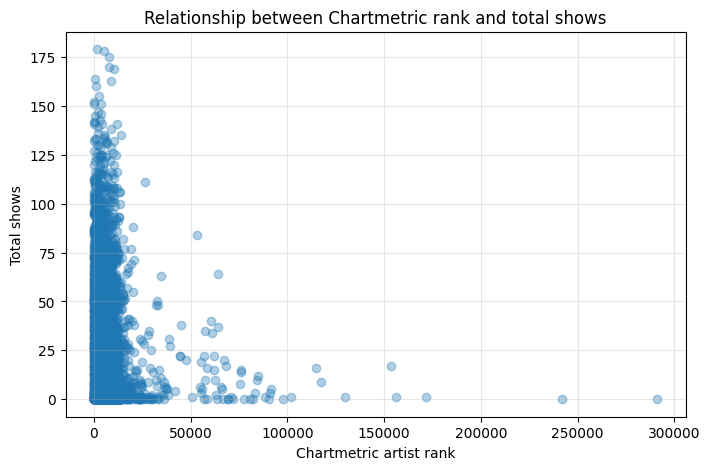

In [164]:
# ============================================================
# Scatterplot: rank vs shows
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["cm_artist_rank"],
    df["n_shows_total"],
    alpha=0.35
)

plt.xlabel("Chartmetric artist rank")
plt.ylabel("Total shows")
plt.title("Relationship between Chartmetric rank and total shows")

plt.grid(alpha=0.3)
plt.show()

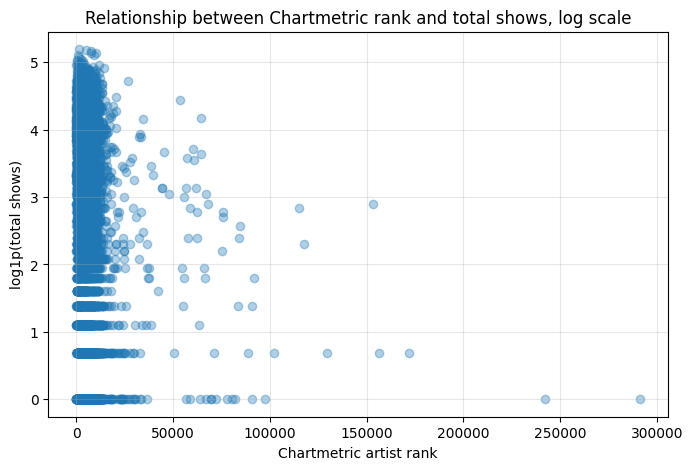

In [165]:
# ============================================================
# Scatterplot: rank vs log1p(shows)
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["cm_artist_rank"],
    np.log1p(df["n_shows_total"]),
    alpha=0.35
)

plt.xlabel("Chartmetric artist rank")
plt.ylabel("log1p(total shows)")
plt.title("Relationship between Chartmetric rank and total shows, log scale")

plt.grid(alpha=0.3)
plt.show()

In [166]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Relación entre rank y presencia de datos en n_shows_total
# ============================================================

df_rank_live = df[df["cm_artist_rank"] <= 100000].copy()

df_rank_live["has_n_shows_total"] = df_rank_live["n_shows_total"].notna()

df_rank_live["has_n_shows_total"].value_counts(dropna=False)

has_n_shows_total
True     4904
False    2070
Name: count, dtype: int64

In [167]:
# ============================================================
# Proporción general de artistas con y sin dato de shows
# ============================================================

df_rank_live["has_n_shows_total"].value_counts(normalize=True)

has_n_shows_total
True     0.703183
False    0.296817
Name: proportion, dtype: float64

In [168]:
# ============================================================
# Presencia de datos de shows por tramos de rank
# ============================================================

df_rank_live["rank_group"] = pd.qcut(
    df_rank_live["cm_artist_rank"],
    q=10,
    labels=[
        "Top 10%",
        "10-20%",
        "20-30%",
        "30-40%",
        "40-50%",
        "50-60%",
        "60-70%",
        "70-80%",
        "80-90%",
        "Bottom 10%"
    ]
)

rank_data_summary = (
    df_rank_live
    .groupby("rank_group", observed=True)["has_n_shows_total"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

rank_data_summary = rank_data_summary.rename(
    columns={
        "count": "n_artists",
        "sum": "n_with_shows_data",
        "mean": "pct_with_shows_data"
    }
)

rank_data_summary["pct_with_shows_data"] = rank_data_summary["pct_with_shows_data"] * 100

rank_data_summary

,rank_group,n_artists,n_with_shows_data,pct_with_shows_data
0,Top 10%,698,618,88.538682
1,10-20%,698,555,79.512894
2,20-30%,696,523,75.143678
3,30-40%,698,500,71.633238
4,40-50%,697,512,73.457676
5,50-60%,697,484,69.440459
6,60-70%,698,442,63.323782
7,70-80%,697,444,63.701578
8,80-90%,697,416,59.684362
9,Bottom 10%,698,410,58.739255


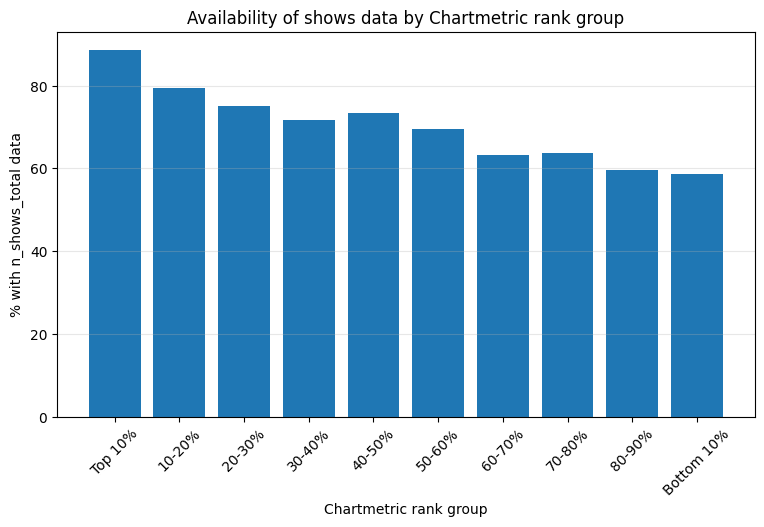

In [169]:
# ============================================================
# Porcentaje de artistas con dato de shows por tramo de rank
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    rank_data_summary["rank_group"],
    rank_data_summary["pct_with_shows_data"]
)

plt.xlabel("Chartmetric rank group")
plt.ylabel("% with n_shows_total data")
plt.title("Availability of shows data by Chartmetric rank group")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

# Conjuntos columnas

In [170]:
# --- definicion de subconjuntos de columnas del dataframe ---

cols_metadata = [
    'chartmetric_id', 'artist_name', 'country', 'pronoun_title',
    'gender_title', 'record_label', 'hometown_city', 'cm_artist_rank',
    'cm_artist_score', 'career_stage', 'career_stage_score', 'career_trend',
    'career_trend_score', 'primary_genre', 'band', 'major_record_label',
    'pronoun_short', 'genre_short', 'country_short', 'muerto_disuelto',
]

cols_streaming = [
    'sp_followers', 'sp_monthly_listeners', 'sp_popularity',
     'deezer_fans', 'shazam_count',
    'pandora_lifetime_streams', 'pandora_lifetime_stations_added',
]

cols_redes_sociales = [
    'ins_followers', 'twitter_followers', 'tiktok_followers',
    'tiktok_likes', 'tiktok_top_video_views',
    'tiktok_top_video_comments', 'tiktok_track_posts',
]

cols_youtube = [
    'ycs_subscribers', 'ycs_views',
    'youtube_daily_video_views', 'youtube_monthly_video_views',
]

cols_playlists = [
    'sp_playlist_total_reach','num_sp_editorial_playlists', 'num_sp_playlists',
    'sp_editorial_playlist_total_reach', 'num_am_editorial_playlists',
    'num_am_playlists', 'num_de_editorial_playlists', 'num_de_playlists',
    'de_playlist_total_reach', 'de_editorial_playlist_total_reach',
    'num_az_editorial_playlists', 'num_az_playlists',
    'num_yt_editorial_playlists', 'num_yt_playlists',
    'yt_playlist_total_reach',
]

cols_concerts = [
    'n_shows_2024', 'avg_low_price_2024', 'avg_high_price_2024',
    'avg_venue_capacity_2024', 'total_capacity_2024',
    'n_shows_with_capacity_2024', 'n_cities_2024', 'n_countries_2024',
    'n_currencies_2024', 'main_currency_2024', 'n_shows_2025',
    'avg_low_price_2025', 'avg_high_price_2025', 'avg_venue_capacity_2025',
    'total_capacity_2025', 'n_shows_with_capacity_2025', 'n_cities_2025',
    'n_countries_2025', 'n_currencies_2025', 'main_currency_2025',
    'shows_per_country_2025', 'shows_per_country_2024', 'n_shows_total',
    'n_shows_with_capacity_total', 'total_capacity_total',
    'avg_venue_capacity_total', 'n_cities_total', 'n_countries_total',
    'shows_per_country_total', 'n_shows_2026'
]

# --- diccionario con todos los grupos, util para iteracion ---
col_groups = {
    'metadata':       cols_metadata,
    'streaming':      cols_streaming,
    'redes_sociales': cols_redes_sociales,
    'youtube':        cols_youtube,
    'playlists':      cols_playlists,
    'concerts':       cols_concerts,
}

In [171]:
# --- verificacion de cobertura de columnas ---

cols_asignadas = [col for group in col_groups.values() for col in group]

cols_sin_asignar = [col for col in df.columns if col not in cols_asignadas]
cols_fantasma    = [col for col in cols_asignadas if col not in df.columns]

if cols_sin_asignar:
    print("columnas del df no asignadas a ningun grupo:")
    for col in cols_sin_asignar:
        print(f"  - {col}")
else:
    print("todas las columnas del df estan asignadas.")

if cols_fantasma:
    print("columnas asignadas que no existen en el df:")
    for col in cols_fantasma:
        print(f"  - {col}")

todas las columnas del df estan asignadas.


In [172]:
df.shape

(7000, 83)

# TIPOS

In [173]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 83 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   chartmetric_id                     7000 non-null   int64  
 1   artist_name                        7000 non-null   str    
 2   country                            6933 non-null   str    
 3   pronoun_title                      7000 non-null   str    
 4   gender_title                       2439 non-null   str    
 5   record_label                       6476 non-null   str    
 6   hometown_city                      4392 non-null   str    
 7   cm_artist_rank                     7000 non-null   int64  
 8   cm_artist_score                    7000 non-null   float64
 9   career_stage                       7000 non-null   str    
 10  career_stage_score                 7000 non-null   int64  
 11  career_trend                       7000 non-null   str    
 12  car

# string a factor 
selectivo

In [174]:
cols_factor = [
    "country",
    "pronoun_title",
    "gender_title",
    "career_stage",
    "career_trend",
    "primary_genre",
    "main_currency_2024",
    "main_currency_2025",
    "pronoun_short",
    "genre_short",
    "country_short",
    "record_label",
    "hometown_city"
]

for c in cols_factor:
    if c in df.columns:
        df[c] = df[c].astype("category")

In [175]:
cols_int = [
    "chartmetric_id",
    "cm_artist_rank",
    "career_stage_score",
    "career_trend_score",

    "sp_followers",
    "sp_monthly_listeners",
    "ins_followers",
    "twitter_followers",
    "tiktok_followers",
    "tiktok_likes",
    "ycs_subscribers",
    "ycs_views",
    "deezer_fans",
    "shazam_count",
    "pandora_lifetime_streams",
    "pandora_lifetime_stations_added",
    "youtube_daily_video_views",
    "youtube_monthly_video_views",

    "num_sp_editorial_playlists",
    "num_sp_playlists",
    "num_am_editorial_playlists",
    "num_am_playlists",
    "num_de_editorial_playlists",
    "num_de_playlists",
    "num_az_editorial_playlists",
    "num_az_playlists",
    "num_yt_editorial_playlists",
    "num_yt_playlists",

    "n_shows_2024",
    "n_shows_2025",
    "n_shows_total",
    "n_shows_2026",

    "n_shows_with_capacity_2024",
    "n_shows_with_capacity_2025",
    "n_shows_with_capacity_total",

    "n_cities_2024",
    "n_cities_2025",
    "n_cities_total",

    "n_countries_2024",
    "n_countries_2025",
    "n_countries_total",

    "n_currencies_2024",
    "n_currencies_2025"
]

for c in cols_int:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").round().astype("Int64")

print("Conversión terminada.")

Conversión terminada.


In [176]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 83 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   chartmetric_id                     7000 non-null   Int64   
 1   artist_name                        7000 non-null   str     
 2   country                            6933 non-null   category
 3   pronoun_title                      7000 non-null   category
 4   gender_title                       2439 non-null   category
 5   record_label                       6476 non-null   category
 6   hometown_city                      4392 non-null   category
 7   cm_artist_rank                     7000 non-null   Int64   
 8   cm_artist_score                    7000 non-null   float64 
 9   career_stage                       7000 non-null   category
 10  career_stage_score                 7000 non-null   Int64   
 11  career_trend                       7000 non-null   cat

# ANALISIS GLOBAL

In [177]:
import sys
!{sys.executable} -m pip install xlsxwriter


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [178]:
import xlsxwriter
print(xlsxwriter.__version__)

3.2.9


# diagnostigo dataset

In [179]:
import pandas as pd
import numpy as np

# --- Configuraciones previas ---
cols_excluir_tabla = ['artist_name']

def generar_diccionario_datos(df, grupos_dict, excluir):
    reporte = []
    
    # Invertimos el diccionario de grupos para búsqueda rápida {columna: nombre_grupo}
    mapa_grupos = {col: grupo for grupo, lista in grupos_dict.items() for col in lista}
    
    for col in df.columns:
        if col in excluir:
            continue
            
        series = df[col]
        total = len(series)
        nas = series.isna().sum()
        
        # Identificar grupo
        grupo_pertenencia = mapa_grupos.get(col, 'Otros')
        
        # Diccionario base con métricas comunes
        resumen = {
            'Grupo': grupo_pertenencia,
            'Feature': col,
            'Tipo': str(series.dtype),
            'Cant_NA': nas,
            '%_NA': f"{(nas / total * 100):.2f}%",
            'Cant_0': (series == 0).sum() if pd.api.types.is_numeric_dtype(series) else "-",
            '%_0': f"{((series == 0).sum() / total * 100):.2f}%" if pd.api.types.is_numeric_dtype(series) else "-",
            'Mínimo': "-", 'Máximo': "-", 'Media': "-", 'Niveles_Cat': "-",
            'SI (True)': "-", 'NO (False)': "-"
        }

        # --- Lógica por Tipo ---
        
        # 1. Numéricas (Excluimos booleanas explícitas)
        if pd.api.types.is_numeric_dtype(series) and not pd.api.types.is_bool_dtype(series):
            # Caso especial: Booleanas que convertimos a float (0, 1, NaN)
            valores_unicos = series.dropna().unique()
            if set(valores_unicos).issubset({0, 1, 0.0, 1.0}):
                si = (series == 1).sum()
                no = (series == 0).sum()
                resumen['Tipo'] = 'Booleana (0/1)'
                resumen['SI (True)'] = f"{si} ({(si/total*100):.2f}%)"
                resumen['NO (False)'] = f"{no} ({(no/total*100):.2f}%)"
            else:
                resumen['Mínimo'] = series.min()
                resumen['Máximo'] = series.max()
                resumen['Media'] = f"{series.mean():.2f}"

        # 2. Categorías o Strings
        elif isinstance(series.dtype, pd.CategoricalDtype) or series.dtype in ['object', 'str']:
            resumen['Niveles_Cat'] = series.nunique()
            try:
                resumen['Mínimo'] = series.dropna().min()
                resumen['Máximo'] = series.dropna().max()
            except:
                pass

        # 3. Booleanas nativas (bool)
        elif pd.api.types.is_bool_dtype(series):
            si = series.sum()
            no = total - nas - si
            resumen['SI (True)'] = f"{si} ({(si/total*100):.2f}%)"
            resumen['NO (False)'] = f"{no} ({(no/total*100):.2f}%)"

        reporte.append(resumen)
    
    return pd.DataFrame(reporte)

# --- Ejecución y Exportación ---
df_final_reporte = generar_diccionario_datos(df, col_groups, cols_excluir_tabla)

# Ordenar por Grupo para que el Excel sea legible
df_final_reporte = df_final_reporte.sort_values(['Grupo', 'Feature'])

nombre_archivo = "Reporte_Estructura_Dataset.xlsx"
with pd.ExcelWriter(nombre_archivo, engine='xlsxwriter') as writer:
    df_final_reporte.to_excel(writer, sheet_name='Features', index=False)
    
    # Formateo estético
    workbook  = writer.book
    worksheet = writer.sheets['Features']
    
    # Colores por grupo para diferenciar visualmente
    header_format = workbook.add_format({'bold': True, 'bg_color': '#2F75B5', 'font_color': 'white', 'border': 1})
    
    for col_num, value in enumerate(df_final_reporte.columns.values):
        worksheet.write(0, col_num, value, header_format)
        worksheet.set_column(col_num, col_num, 20)

print(f" Tabla exportable generada: {nombre_archivo}")

 Tabla exportable generada: Reporte_Estructura_Dataset.xlsx


# DF_tp

creo df_tp
quito las columnas que incluyen rankings scores de chartmetric que no me interesan y algunas que creé yo en conciertos pero que no tienen cantidad de información relevante.
además renombro la target y reemplazo lo que es total para que sea más decriptivo por 24_25

In [180]:
# 1. Definimos las listas de palabras y el patrón de años
forbidden = ['score', 'rank', 'trend', 'currency', 'hometown', 'currencies', 'stage', 'gender', 'price']
conditional = ['capacity', 'shows', 'cities', 'countries']
years = ['2024', '2025', '2026']

# 2. Aplicamos la lógica de filtrado refinada
cols_to_keep = [
    col for col in df.columns 
    if not any(w in col for w in forbidden) # Regla de oro: si tiene estas, fuera.
    and not (
        any(w in col for w in conditional)  # Si es de las condicionales...
        and ('total' not in col or any(y in col for y in years)) # ...fuera si no dice total O si dice un año.
    )
]

# 3. Creamos el DataFrame
df_tp = df[cols_to_keep].copy()

# --- BLOQUE DE VERIFICACIÓN ---
cols_removed = df.columns.difference(df_tp.columns)

print(f"✅ Columnas originales: {len(df.columns)}")
print(f"✅ Columnas mantenidas: {len(df_tp.columns)}")
print(f"❌ Columnas eliminadas: {len(cols_removed)}")

print("\n--- DETALLE DE COLUMNAS ELIMINADAS (Nuevas incorporaciones) ---")
# Verificamos específicamente las que querías quitar ahora
for c in ['total_capacity_2024', 'total_capacity_2025']:
    if c in cols_removed:
        print(f"Eliminada correctamente: {c}")

print("\n--- TODAS LAS ELIMINADAS ---")
print(list(cols_removed))

✅ Columnas originales: 83
✅ Columnas mantenidas: 52
❌ Columnas eliminadas: 31

--- DETALLE DE COLUMNAS ELIMINADAS (Nuevas incorporaciones) ---
Eliminada correctamente: total_capacity_2024
Eliminada correctamente: total_capacity_2025

--- TODAS LAS ELIMINADAS ---
['avg_high_price_2024', 'avg_high_price_2025', 'avg_low_price_2024', 'avg_low_price_2025', 'avg_venue_capacity_2024', 'avg_venue_capacity_2025', 'career_stage', 'career_stage_score', 'career_trend', 'career_trend_score', 'cm_artist_rank', 'cm_artist_score', 'gender_title', 'hometown_city', 'main_currency_2024', 'main_currency_2025', 'n_cities_2024', 'n_cities_2025', 'n_countries_2024', 'n_countries_2025', 'n_currencies_2024', 'n_currencies_2025', 'n_shows_2024', 'n_shows_2025', 'n_shows_2026', 'n_shows_with_capacity_2024', 'n_shows_with_capacity_2025', 'shows_per_country_2024', 'shows_per_country_2025', 'total_capacity_2024', 'total_capacity_2025']


In [181]:
df_tp.columns

Index(['chartmetric_id', 'artist_name', 'country', 'pronoun_title',
       'record_label', 'primary_genre', 'sp_followers', 'sp_monthly_listeners',
       'sp_popularity', 'sp_playlist_total_reach', 'ins_followers',
       'twitter_followers', 'tiktok_followers', 'tiktok_likes',
       'ycs_subscribers', 'ycs_views', 'youtube_daily_video_views',
       'youtube_monthly_video_views', 'deezer_fans', 'shazam_count',
       'pandora_lifetime_streams', 'pandora_lifetime_stations_added', 'band',
       'num_sp_editorial_playlists', 'num_sp_playlists',
       'sp_editorial_playlist_total_reach', 'num_am_editorial_playlists',
       'num_am_playlists', 'num_de_editorial_playlists', 'num_de_playlists',
       'de_playlist_total_reach', 'de_editorial_playlist_total_reach',
       'num_az_editorial_playlists', 'num_az_playlists',
       'num_yt_editorial_playlists', 'num_yt_playlists',
       'yt_playlist_total_reach', 'tiktok_top_video_views',
       'tiktok_top_video_comments', 'tiktok_track_po

In [182]:
# 1. Renombrar específicamente total_capacity_total a capacity_total
df_tp = df_tp.rename(columns={'total_capacity_total': 'capacity_total'})

# 2. Lista de columnas específicas a modificar
cols_a_modificar = [
    'n_shows_total', 
    'n_shows_with_capacity_total', 
    'capacity_total', 
    'avg_venue_capacity_total', 
    'n_cities_total', 
    'n_countries_total', 
    'shows_per_country_total'
]

# 3. Aplicar el reemplazo de 'total' por '24_25' solo en esas columnas
df_tp.columns = [
    col.replace('total', '24_25') if col in cols_a_modificar else col 
    for col in df_tp.columns
]

# Verificar los nuevos nombres en esa lista
print(df_tp.columns[df_tp.columns.str.contains('24_25')])

Index(['n_shows_24_25', 'n_shows_with_capacity_24_25', 'capacity_24_25',
       'avg_venue_capacity_24_25', 'n_cities_24_25', 'n_countries_24_25',
       'shows_per_country_24_25'],
      dtype='str')


# imputo ceros en live

In [183]:
# ============================================================
# Imputación controlada de ceros estructurales en variables live
# ============================================================

mask_live_cero_estructural = (
    (df_tp["n_shows_24_25"] == 0) &
    (
        (df_tp["muerto_disuelto"] == True) |
        (df_tp["muerto_disuelto"].isna())
    )
)

cols_live_imputar_cero = [
    "n_shows_with_capacity_24_25",
    "capacity_24_25",
    "n_cities_24_25",
    "n_countries_24_25"
]

df_tp.loc[mask_live_cero_estructural, cols_live_imputar_cero] = (
    df_tp.loc[mask_live_cero_estructural, cols_live_imputar_cero].fillna(0)
)

# Control posterior de nulos en las variables imputadas
df_tp.loc[mask_live_cero_estructural, cols_live_imputar_cero].isna().sum()

n_shows_with_capacity_24_25    0
capacity_24_25                 0
n_cities_24_25                 0
n_countries_24_25              0
dtype: int64

# OFF_cycle

In [184]:
# ============================================================
# Recreación de variable auxiliar off_cycle
# ============================================================

df_tp["off_cycle"] = (
    (df_tp["n_shows_24_25"] == 0) &
    (df_tp["muerto_disuelto"].ne(True).fillna(True))
)

df_tp["off_cycle"] = df_tp["off_cycle"].astype("boolean")

df_tp["off_cycle"].value_counts(dropna=False)

off_cycle
False    4690
<NA>     2087
True      223
Name: count, dtype: Int64

In [185]:
# ============================================================
# Control de consistencia de off_cycle
# ============================================================

control_off_cycle = (
    df_tp
    .groupby(["off_cycle", "muerto_disuelto"], dropna=False)
    .agg(
        n_artistas=("chartmetric_id", "count"),
        min_shows=("n_shows_24_25", "min"),
        max_shows=("n_shows_24_25", "max"),
        total_shows=("n_shows_24_25", "sum")
    )
    .reset_index()
)

control_off_cycle

,off_cycle,muerto_disuelto,n_artistas,min_shows,max_shows,total_shows
0,False,False,4053,1,179,119381
1,False,True,637,0,0,0
2,True,<NA>,223,0,0,0
3,<NA>,<NA>,2087,<NA>,<NA>,0


In [186]:
# df_tp["off_cycle"] = df_tp["off_cycle"].astype(bool)

In [187]:
# Estructura general del dataset
print("Filas y columnas:", df_tp.shape)

# Control de clave única
print("Artistas únicos:", df_tp["chartmetric_id"].nunique())
print("Duplicados por chartmetric_id:", df_tp.duplicated(subset="chartmetric_id").sum())

# Control de target
print("Nulos en target:", df_tp["n_shows_24_25"].isna().sum())
print("Tipo de dato de target:", df_tp["n_shows_24_25"].dtype)

Filas y columnas: (7000, 53)
Artistas únicos: 7000
Duplicados por chartmetric_id: 0
Nulos en target: 2087
Tipo de dato de target: Int64


In [188]:
df_tp.shape

(7000, 53)

In [189]:
df_tp.columns

Index(['chartmetric_id', 'artist_name', 'country', 'pronoun_title',
       'record_label', 'primary_genre', 'sp_followers', 'sp_monthly_listeners',
       'sp_popularity', 'sp_playlist_total_reach', 'ins_followers',
       'twitter_followers', 'tiktok_followers', 'tiktok_likes',
       'ycs_subscribers', 'ycs_views', 'youtube_daily_video_views',
       'youtube_monthly_video_views', 'deezer_fans', 'shazam_count',
       'pandora_lifetime_streams', 'pandora_lifetime_stations_added', 'band',
       'num_sp_editorial_playlists', 'num_sp_playlists',
       'sp_editorial_playlist_total_reach', 'num_am_editorial_playlists',
       'num_am_playlists', 'num_de_editorial_playlists', 'num_de_playlists',
       'de_playlist_total_reach', 'de_editorial_playlist_total_reach',
       'num_az_editorial_playlists', 'num_az_playlists',
       'num_yt_editorial_playlists', 'num_yt_playlists',
       'yt_playlist_total_reach', 'tiktok_top_video_views',
       'tiktok_top_video_comments', 'tiktok_track_po

In [190]:
df_tp.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 53 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   chartmetric_id                     7000 non-null   Int64   
 1   artist_name                        7000 non-null   str     
 2   country                            6933 non-null   category
 3   pronoun_title                      7000 non-null   category
 4   record_label                       6476 non-null   category
 5   primary_genre                      7000 non-null   category
 6   sp_followers                       6978 non-null   Int64   
 7   sp_monthly_listeners               6978 non-null   Int64   
 8   sp_popularity                      6992 non-null   float64 
 9   sp_playlist_total_reach            6989 non-null   float64 
 10  ins_followers                      6394 non-null   Int64   
 11  twitter_followers                  5227 non-null   Int

# nulos target género y territorio

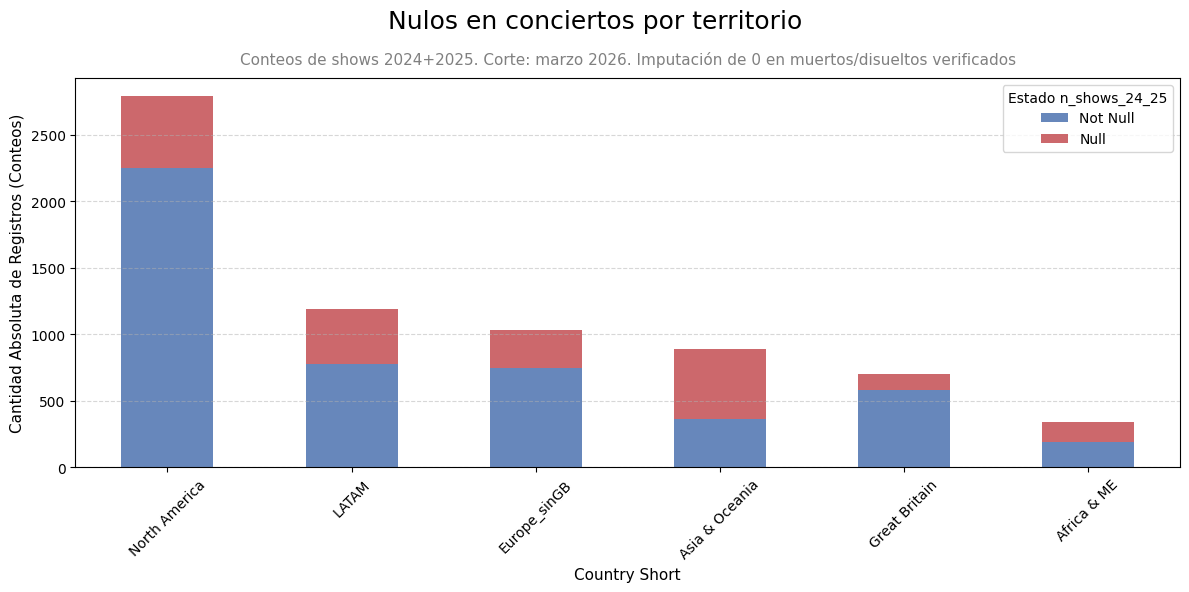

In [191]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. PREPARACIÓN DE DATOS (Mismo Reporte)
# ==========================================

# Definimos el estado de los nulos
is_null = df_tp['n_shows_24_25'].isna().map({True: 'Null', False: 'Not Null'})

# Tabla de frecuencias absolutas (conteos puros)
cruce_cantidades = pd.crosstab(index=df_tp['country_short'], columns=is_null)

# Calculamos los totales por país para ordenar el gráfico de mayor a menor peso
cruce_cantidades['Total_Pais'] = cruce_cantidades['Null'] + cruce_cantidades['Not Null']
cruce_cantidades = cruce_cantidades.sort_values(by='Total_Pais', ascending=False)

# Eliminamos la columna temporal de total para que no se grafique como una barra extra
cruce_grafico = cruce_cantidades.drop(columns=['Total_Pais'])


# ==========================================
# 2. GRÁFICO DE BARRAS APILADAS (CONTEOS ABSOLUTOS)
# ==========================================

fig, ax = plt.subplots(figsize=(12, 6))

# Graficamos directamente los conteos. 'stacked=True' apila el color interno.
cruce_grafico.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#C44E52'], alpha=0.85)

# Título Principal (va en la figura completa)
plt.suptitle('Nulos en conciertos por territorio', fontsize=18, y=0.98)

# Subtítulo (va en el set_title del gráfico, con letra más chica)
ax.set_title('Conteos de shows 2024+2025. Corte: marzo 2026. Imputación de 0 en muertos/disueltos verificados', fontsize=11, color='gray', pad=10)

ax.set_xlabel('Country Short', fontsize=11)
ax.set_ylabel('Cantidad Absoluta de Registros (Conteos)', fontsize=11)
ax.legend(title='Estado n_shows_24_25', loc='upper right')
ax.tick_params(axis='x', rotation=45)


# Agregamos una cuadrícula horizontal sutil para facilitar la lectura de los conteos
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

ruta_nulos_territorio = (
    directorio_salidas_proyecto /
    "nulos_en_concierto_por territorio.png"
)

plt.savefig(
    ruta_nulos_territorio,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

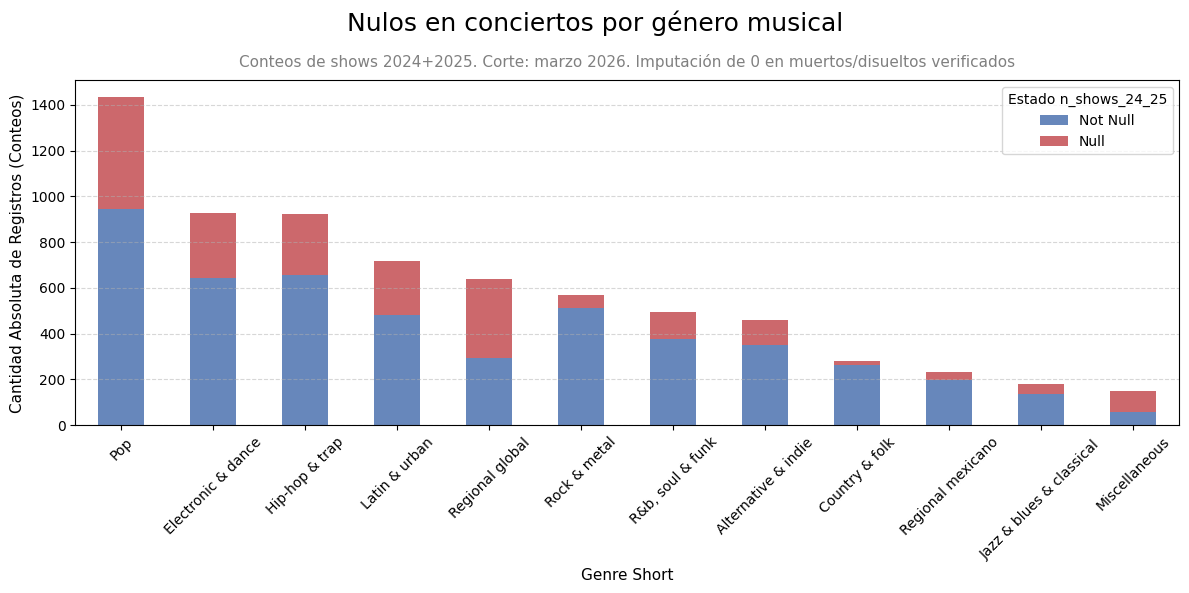

In [192]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. PREPARACIÓN DE DATOS (Mapeo por Género)
# ==========================================

# Definimos el estado de los nulos
is_null = df_tp['n_shows_24_25'].isna().map({True: 'Null', False: 'Not Null'})

# Tabla de frecuencias absolutas para genre_short
cruce_cantidades_genero = pd.crosstab(index=df_tp['genre_short'], columns=is_null)

# Calculamos los totales por género para ordenar de mayor a menor peso
cruce_cantidades_genero['Total_Genero'] = cruce_cantidades_genero['Null'] + cruce_cantidades_genero['Not Null']
cruce_cantidades_genero = cruce_cantidades_genero.sort_values(by='Total_Genero', ascending=False)

# Eliminamos la columna de total para el gráfico
cruce_grafico_genero = cruce_cantidades_genero.drop(columns=['Total_Genero'])


# ==========================================
# 2. GRÁFICO DE BARRAS APILADAS (CONTEOS ABSOLUTOS)
# ==========================================

fig, ax = plt.subplots(figsize=(12, 6))

# Graficamos los conteos absolutos apilados
cruce_grafico_genero.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#C44E52'], alpha=0.85)

# Configuración visual

# Título Principal (va en la figura completa)
plt.suptitle('Nulos en conciertos por género musical', fontsize=18, y=0.98)

# Subtítulo (va en el set_title del gráfico, con letra más chica)
ax.set_title('Conteos de shows 2024+2025. Corte: marzo 2026. Imputación de 0 en muertos/disueltos verificados', fontsize=11, color='gray', pad=10)
ax.set_xlabel('Genre Short', fontsize=11)
ax.set_ylabel('Cantidad Absoluta de Registros (Conteos)', fontsize=11)
ax.legend(title='Estado n_shows_24_25', loc='upper right')

# Rotamos las etiquetas si los nombres de los géneros son largos
ax.tick_params(axis='x', rotation=45)

# Cuadrícula de fondo sutil
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

ruta_nulos_genre = (
    directorio_salidas_proyecto /
    "nulos_en_concierto_por_genre.png"
)

plt.savefig(
    ruta_nulos_genre,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

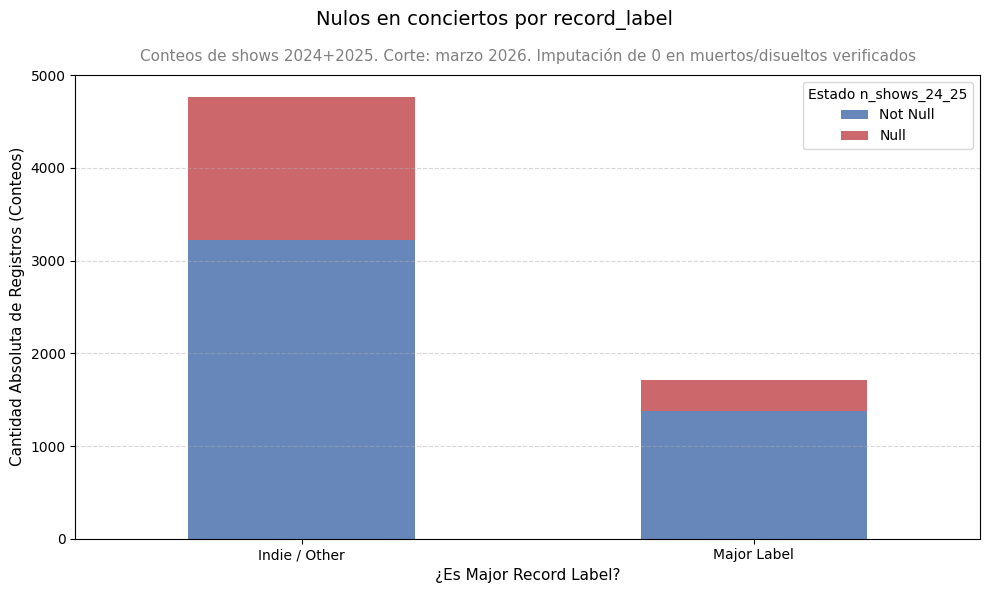

In [193]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. PREPARACIÓN DE DATOS (Mapeo por Sello Discográfico)
# ==========================================

# Definimos el estado de los nulos
is_null = df_tp['n_shows_24_25'].isna().map({True: 'Null', False: 'Not Null'})

# Tabla de frecuencias absolutas para major_record_label
cruce_cantidades_label = pd.crosstab(index=df_tp['major_record_label'], columns=is_null)

# Renombramos el índice booleano para que el reporte y el gráfico sean legibles
cruce_cantidades_label.index = cruce_cantidades_label.index.map({True: 'Major Label', False: 'Indie / Other'})

# Calculamos los totales para ordenar de mayor a menor peso
cruce_cantidades_label['Total_Label'] = cruce_cantidades_label['Null'] + cruce_cantidades_label['Not Null']
cruce_cantidades_label = cruce_cantidades_label.sort_values(by='Total_Label', ascending=False)

# Eliminamos la columna de total para el gráfico
cruce_grafico_label = cruce_cantidades_label.drop(columns=['Total_Label'])


# ==========================================
# 2. GRÁFICO DE BARRAS APILADAS
# ==========================================

fig, ax = plt.subplots(figsize=(10, 6))

# Graficamos los conteos absolutos apilados
cruce_grafico_label.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#C44E52'], alpha=0.85)

# Configuración visual
# Título Principal (va en la figura completa)
plt.suptitle('Nulos en conciertos por record_label', fontsize=14, y=0.98)

# Subtítulo (va en el set_title del gráfico, con letra más chica)
ax.set_title('Conteos de shows 2024+2025. Corte: marzo 2026. Imputación de 0 en muertos/disueltos verificados', fontsize=11, color='gray', pad=10)


ax.set_xlabel('¿Es Major Record Label?', fontsize=11)
ax.set_ylabel('Cantidad Absoluta de Registros (Conteos)', fontsize=11)
ax.legend(title='Estado n_shows_24_25', loc='upper right')

# Dejamos las etiquetas horizontales ya que son solo dos categorías y cortas
ax.tick_params(axis='x', rotation=0)

# Cuadrícula de fondo sutil
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

C:\Users\Silvana\AppData\Local\Temp\ipykernel_33988\107345109.py:229: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


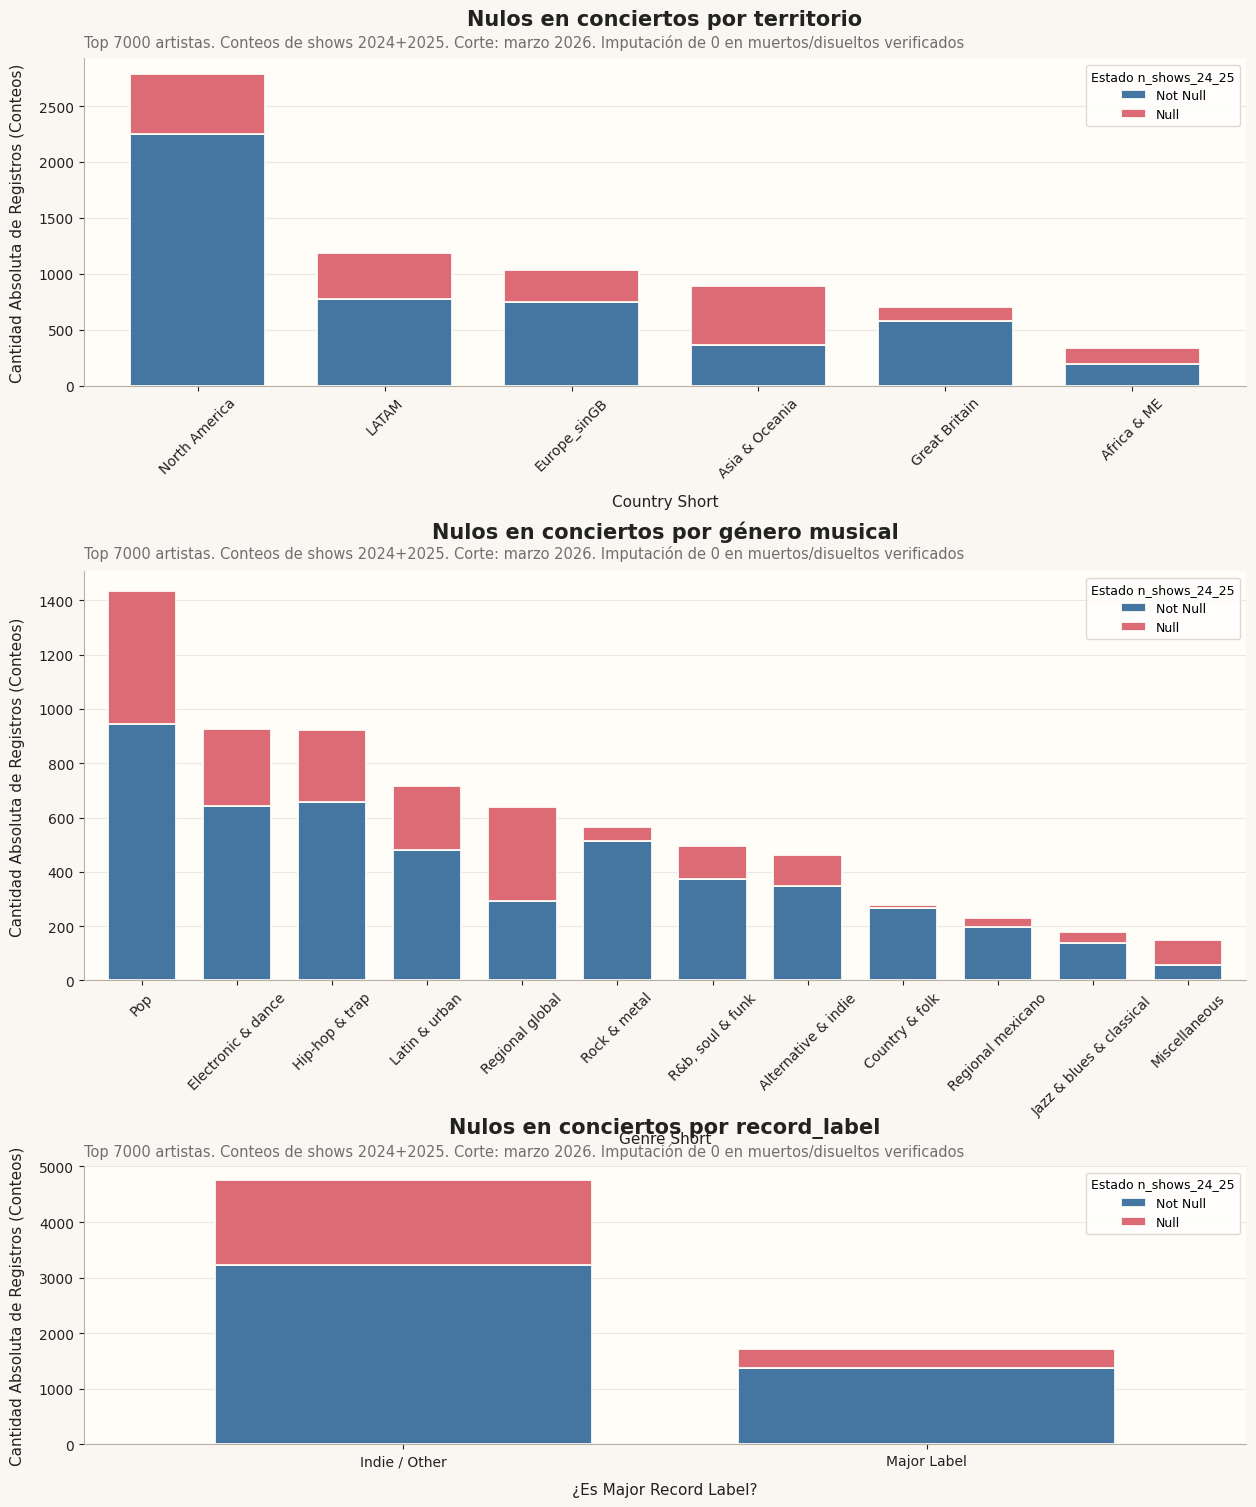

Gráfico guardado en: graficos\nulos_target_territorio_genero_record_label.png


In [194]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==========================================
# 1. PREPARACIÓN GENERAL
# ==========================================

directorio_graficos_nulos = Path("graficos")
directorio_graficos_nulos.mkdir(exist_ok=True)

colores_estado_target = {
    "Not Null": "#356A9A",
    "Null": "#D95F6A"
}

color_fondo_figura = "#FAF7F2"
color_fondo_ejes = "#FFFDF8"
color_grilla = "#C9C3B8"
color_texto = "#222222"
color_subtitulo = "#6F6F6F"


# ==========================================
# 2. FUNCIÓN AUXILIAR PARA PREPARAR CRUCES
# ==========================================

def preparar_cruce_nulos_target(
    dataframe_base,
    variable_categorica,
    nombre_columna_total,
    mapeo_indice=None
):
    estado_nulos_target = (
        dataframe_base["n_shows_24_25"]
        .isna()
        .map({True: "Null", False: "Not Null"})
    )
    
    cruce_cantidades = pd.crosstab(
        index=dataframe_base[variable_categorica],
        columns=estado_nulos_target
    )
    
    cruce_cantidades = cruce_cantidades.reindex(
        columns=["Not Null", "Null"],
        fill_value=0
    )
    
    if mapeo_indice is not None:
        cruce_cantidades.index = cruce_cantidades.index.map(mapeo_indice)
    
    cruce_cantidades[nombre_columna_total] = (
        cruce_cantidades["Null"] + cruce_cantidades["Not Null"]
    )
    
    cruce_cantidades = cruce_cantidades.sort_values(
        by=nombre_columna_total,
        ascending=False
    )
    
    cruce_grafico = cruce_cantidades.drop(columns=[nombre_columna_total])
    
    return cruce_grafico


# ==========================================
# 3. TABLAS PARA LOS TRES GRÁFICOS
# ==========================================

cruce_grafico_territorio = preparar_cruce_nulos_target(
    dataframe_base=df_tp,
    variable_categorica="country_short",
    nombre_columna_total="Total_Pais"
)

cruce_grafico_genero = preparar_cruce_nulos_target(
    dataframe_base=df_tp,
    variable_categorica="genre_short",
    nombre_columna_total="Total_Genero"
)

cruce_grafico_label = preparar_cruce_nulos_target(
    dataframe_base=df_tp,
    variable_categorica="major_record_label",
    nombre_columna_total="Total_Label",
    mapeo_indice={True: "Major Label", False: "Indie / Other"}
)


# ==========================================
# 4. FUNCIÓN AUXILIAR DE ESTILO
# ==========================================

def graficar_barras_apiladas_nulos(
    ax,
    cruce_grafico,
    titulo_principal,
    subtitulo,
    etiqueta_x,
    etiqueta_y,
    rotacion_x
):
    cruce_grafico.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[
            colores_estado_target["Not Null"],
            colores_estado_target["Null"]
        ],
        alpha=0.92,
        width=0.72,
        edgecolor=color_fondo_ejes,
        linewidth=1.4
    )
    
    ax.set_facecolor(color_fondo_ejes)
    
    ax.set_title(
        titulo_principal,
        fontsize=15,
        color=color_texto,
        fontweight="bold",
        pad=24
    )
    
    ax.text(
        0,
        1.025,
        subtitulo,
        transform=ax.transAxes,
        fontsize=10.5,
        color=color_subtitulo,
        ha="left",
        va="bottom"
    )
    
    ax.set_xlabel(etiqueta_x, fontsize=11, color=color_texto, labelpad=10)
    ax.set_ylabel(etiqueta_y, fontsize=11, color=color_texto, labelpad=10)
    
    ax.legend(
        title="Estado n_shows_24_25",
        loc="upper right",
        frameon=True,
        facecolor="white",
        edgecolor="#D6D1C8",
        fontsize=9,
        title_fontsize=9
    )
    
    ax.tick_params(
        axis="x",
        rotation=rotacion_x,
        labelsize=10,
        colors=color_texto
    )
    
    ax.tick_params(
        axis="y",
        labelsize=10,
        colors=color_texto
    )
    
    ax.grid(
        axis="y",
        linestyle="-",
        linewidth=0.8,
        alpha=0.35,
        color=color_grilla
    )
    
    ax.grid(axis="x", visible=False)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#B8B0A4")
    ax.spines["bottom"].set_color("#B8B0A4")
    
    ax.set_axisbelow(True)


# ==========================================
# 5. FIGURA ÚNICA CON LOS TRES GRÁFICOS
# ==========================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(15, 18),
    gridspec_kw={
        "height_ratios": [1, 1.25, 0.85],
        "hspace": 0.55
    }
)

fig.patch.set_facecolor(color_fondo_figura)

graficar_barras_apiladas_nulos(
    ax=axes[0],
    cruce_grafico=cruce_grafico_territorio,
    titulo_principal="Nulos en conciertos por territorio",
    subtitulo="Top 7000 artistas. Conteos de shows 2024+2025. Corte: marzo 2026. Imputación de 0 en muertos/disueltos verificados",
    etiqueta_x="Country Short",
    etiqueta_y="Cantidad Absoluta de Registros (Conteos)",
    rotacion_x=45
)

graficar_barras_apiladas_nulos(
    ax=axes[1],
    cruce_grafico=cruce_grafico_genero,
    titulo_principal="Nulos en conciertos por género musical",
    subtitulo="Top 7000 artistas. Conteos de shows 2024+2025. Corte: marzo 2026. Imputación de 0 en muertos/disueltos verificados",
    etiqueta_x="Genre Short",
    etiqueta_y="Cantidad Absoluta de Registros (Conteos)",
    rotacion_x=45
)

graficar_barras_apiladas_nulos(
    ax=axes[2],
    cruce_grafico=cruce_grafico_label,
    titulo_principal="Nulos en conciertos por record_label",
    subtitulo="Top 7000 artistas. Conteos de shows 2024+2025. Corte: marzo 2026. Imputación de 0 en muertos/disueltos verificados",
    etiqueta_x="¿Es Major Record Label?",
    etiqueta_y="Cantidad Absoluta de Registros (Conteos)",
    rotacion_x=0
)

plt.tight_layout()

ruta_grafico_nulos_target_combinado = (
    directorio_graficos_nulos /
    "nulos_target_territorio_genero_record_label.png"
)

plt.savefig(
    ruta_grafico_nulos_target_combinado,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print("Gráfico guardado en:", ruta_grafico_nulos_target_combinado)

C:\Users\Silvana\AppData\Local\Temp\ipykernel_33988\491310322.py:229: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


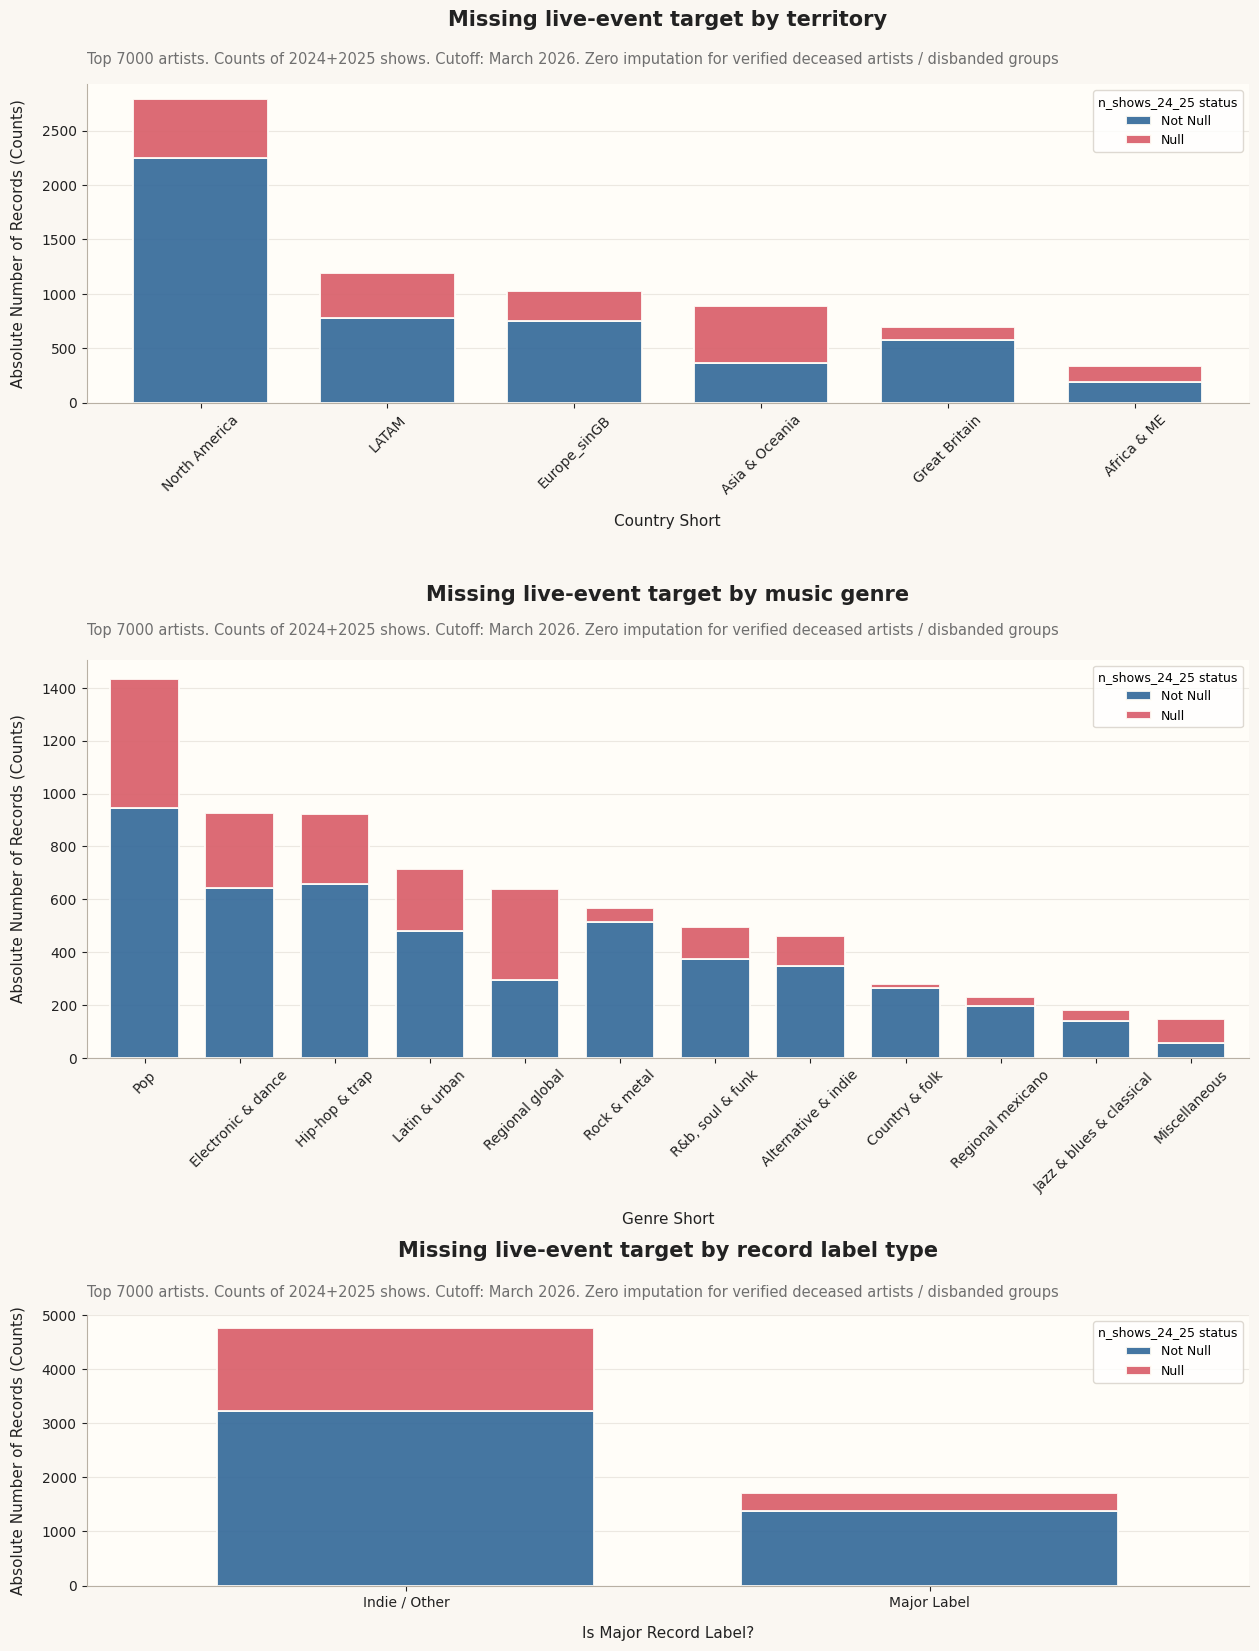

Chart saved at: graficos\missing_target_territory_genre_record_label.png


In [199]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==========================================
# 1. GENERAL SETUP
# ==========================================

directorio_graficos_nulos = Path("graficos")
directorio_graficos_nulos.mkdir(exist_ok=True)

colores_estado_target = {
    "Not Null": "#356A9A",
    "Null": "#D95F6A"
}

color_fondo_figura = "#FAF7F2"
color_fondo_ejes = "#FFFDF8"
color_grilla = "#C9C3B8"
color_texto = "#222222"
color_subtitulo = "#6F6F6F"


# ==========================================
# 2. AUXILIARY FUNCTION TO PREPARE CROSSTABS
# ==========================================

def preparar_cruce_nulos_target(
    dataframe_base,
    variable_categorica,
    nombre_columna_total,
    mapeo_indice=None
):
    estado_nulos_target = (
        dataframe_base["n_shows_24_25"]
        .isna()
        .map({True: "Null", False: "Not Null"})
    )
    
    cruce_cantidades = pd.crosstab(
        index=dataframe_base[variable_categorica],
        columns=estado_nulos_target
    )
    
    cruce_cantidades = cruce_cantidades.reindex(
        columns=["Not Null", "Null"],
        fill_value=0
    )
    
    if mapeo_indice is not None:
        cruce_cantidades.index = cruce_cantidades.index.map(mapeo_indice)
    
    cruce_cantidades[nombre_columna_total] = (
        cruce_cantidades["Null"] + cruce_cantidades["Not Null"]
    )
    
    cruce_cantidades = cruce_cantidades.sort_values(
        by=nombre_columna_total,
        ascending=False
    )
    
    cruce_grafico = cruce_cantidades.drop(columns=[nombre_columna_total])
    
    return cruce_grafico


# ==========================================
# 3. TABLES FOR THE THREE CHARTS
# ==========================================

cruce_grafico_territorio = preparar_cruce_nulos_target(
    dataframe_base=df_tp,
    variable_categorica="country_short",
    nombre_columna_total="Total_Pais"
)

cruce_grafico_genero = preparar_cruce_nulos_target(
    dataframe_base=df_tp,
    variable_categorica="genre_short",
    nombre_columna_total="Total_Genero"
)

cruce_grafico_label = preparar_cruce_nulos_target(
    dataframe_base=df_tp,
    variable_categorica="major_record_label",
    nombre_columna_total="Total_Label",
    mapeo_indice={True: "Major Label", False: "Indie / Other"}
)


# ==========================================
# 4. AUXILIARY STYLE FUNCTION
# ==========================================

def graficar_barras_apiladas_nulos(
    ax,
    cruce_grafico,
    titulo_principal,
    subtitulo,
    etiqueta_x,
    etiqueta_y,
    rotacion_x
):
    cruce_grafico.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[
            colores_estado_target["Not Null"],
            colores_estado_target["Null"]
        ],
        alpha=0.92,
        width=0.72,
        edgecolor=color_fondo_ejes,
        linewidth=1.4
    )
    
    ax.set_facecolor(color_fondo_ejes)
    
    ax.set_title(
        titulo_principal,
        fontsize=15,
        color=color_texto,
        fontweight="bold",
        pad=42
    )
    
    ax.text(
        0,
        1.055,
        subtitulo,
        transform=ax.transAxes,
        fontsize=10.5,
        color=color_subtitulo,
        ha="left",
        va="bottom"
    )
    
    ax.set_xlabel(etiqueta_x, fontsize=11, color=color_texto, labelpad=12)
    ax.set_ylabel(etiqueta_y, fontsize=11, color=color_texto, labelpad=12)
    
    ax.legend(
        title="n_shows_24_25 status",
        loc="upper right",
        frameon=True,
        facecolor="white",
        edgecolor="#D6D1C8",
        fontsize=9,
        title_fontsize=9
    )
    
    ax.tick_params(
        axis="x",
        rotation=rotacion_x,
        labelsize=10,
        colors=color_texto
    )
    
    ax.tick_params(
        axis="y",
        labelsize=10,
        colors=color_texto
    )
    
    ax.grid(
        axis="y",
        linestyle="-",
        linewidth=0.8,
        alpha=0.35,
        color=color_grilla
    )
    
    ax.grid(axis="x", visible=False)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#B8B0A4")
    ax.spines["bottom"].set_color("#B8B0A4")
    
    ax.set_axisbelow(True)


# ==========================================
# 5. SINGLE FIGURE WITH THE THREE CHARTS
# ==========================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(15, 19.5),
    gridspec_kw={
        "height_ratios": [1, 1.25, 0.85],
        "hspace": 0.78
    }
)

fig.patch.set_facecolor(color_fondo_figura)

graficar_barras_apiladas_nulos(
    ax=axes[0],
    cruce_grafico=cruce_grafico_territorio,
    titulo_principal="Missing live-event target by territory",
    subtitulo="Top 7000 artists. Counts of 2024+2025 shows. Cutoff: March 2026. Zero imputation for verified deceased artists / disbanded groups",
    etiqueta_x="Country Short",
    etiqueta_y="Absolute Number of Records (Counts)",
    rotacion_x=45
)

graficar_barras_apiladas_nulos(
    ax=axes[1],
    cruce_grafico=cruce_grafico_genero,
    titulo_principal="Missing live-event target by music genre",
    subtitulo="Top 7000 artists. Counts of 2024+2025 shows. Cutoff: March 2026. Zero imputation for verified deceased artists / disbanded groups",
    etiqueta_x="Genre Short",
    etiqueta_y="Absolute Number of Records (Counts)",
    rotacion_x=45
)

graficar_barras_apiladas_nulos(
    ax=axes[2],
    cruce_grafico=cruce_grafico_label,
    titulo_principal="Missing live-event target by record label type",
    subtitulo="Top 7000 artists. Counts of 2024+2025 shows. Cutoff: March 2026. Zero imputation for verified deceased artists / disbanded groups",
    etiqueta_x="Is Major Record Label?",
    etiqueta_y="Absolute Number of Records (Counts)",
    rotacion_x=0
)

plt.tight_layout()

ruta_grafico_nulos_target_combinado = (
    directorio_graficos_nulos /
    "missing_target_territory_genre_record_label.png"
)

plt.savefig(
    ruta_grafico_nulos_target_combinado,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print("Chart saved at:", ruta_grafico_nulos_target_combinado)

## nulos target por rank


Sanity check de merge:
  Filas df_tp              : 7000
  Filas después del merge  : 7000
  Columna rank recuperada  : cm_artist_rank
  Rank faltante post-merge : 0


,rank_bin,rank_min,rank_max,n_registros,n_null,n_not_null,pct_null,pct_not_null,rank_bin_label
0,"(0.999, 804.9]",1,804,700,80,620,11.428571,88.571429,1 - 804
1,"(804.9, 1723.8]",805,1723,700,143,557,20.428571,79.571429,805 - 1723
2,"(1723.8, 2824.0]",1724,2824,701,176,525,25.10699,74.89301,1724 - 2824
3,"(2824.0, 4013.6]",2827,4013,699,197,502,28.183119,71.816881,2827 - 4013
4,"(4013.6, 5266.5]",4014,5266,700,185,515,26.428571,73.571429,4014 - 5266
5,"(5266.5, 6517.8]",5267,6517,700,217,483,31.0,69.0,5267 - 6517
6,"(6517.8, 7857.3]",6519,7857,700,257,443,36.714286,63.285714,6519 - 7857
7,"(7857.3, 9649.4]",7858,9649,700,254,446,36.285714,63.714286,7858 - 9649
8,"(9649.4, 12032.1]",9651,12032,700,283,417,40.428571,59.571429,9651 - 12032
9,"(12032.1, 458903.0]",12033,458903,700,295,405,42.142857,57.857143,12033 - 458903


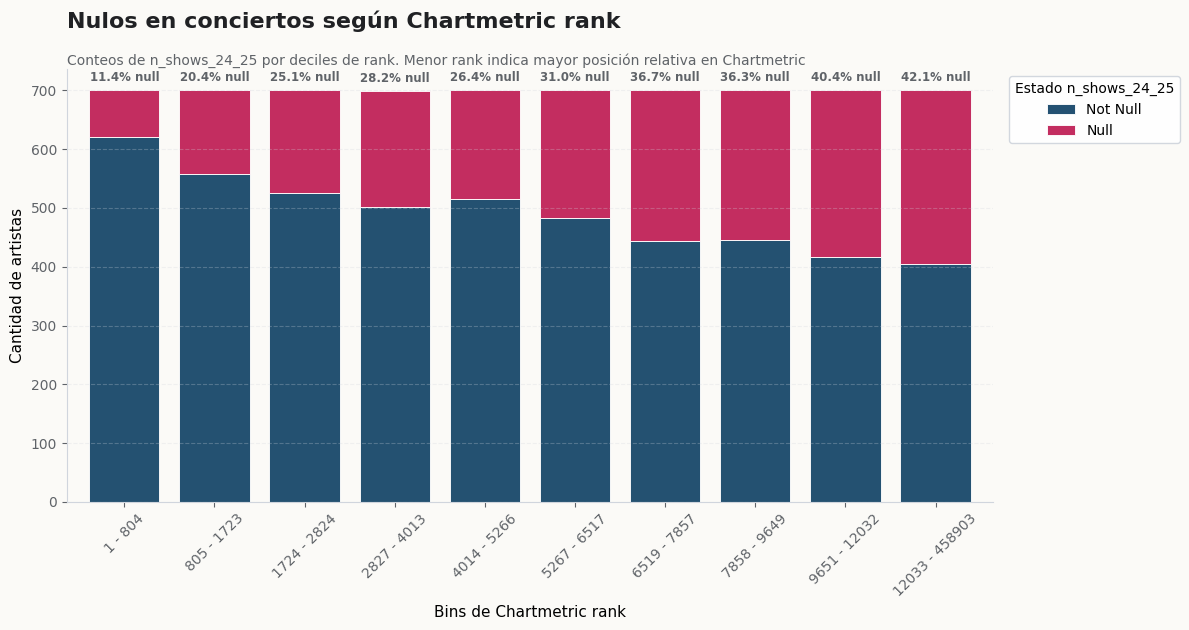

Variable de rank usada: cm_artist_rank
Gráfico guardado en: graficos\nulos_n_shows_24_25_por_bins_cm_artist_rank.png


In [205]:
# ============================================================
# Nulos en n_shows_24_25 según bins de Chartmetric rank
# Base principal: df_tp
# Rank recuperado desde df por chartmetric_id
# ============================================================

# ------------------------------------------------------------
# Parámetros
# ------------------------------------------------------------

target_nulos = "n_shows_24_25"
id_col = "chartmetric_id"

posibles_columnas_rank = [
    "chartmetric_rank",
    "cm_artist_rank",
    "cm_rank"
]

rank_col = next(
    columna for columna in posibles_columnas_rank
    if columna in df.columns
)

n_bins_rank = 10

assert id_col in df_tp.columns, (
    f"La columna {id_col} no existe en df_tp."
)

assert id_col in df.columns, (
    f"La columna {id_col} no existe en df."
)

assert target_nulos in df_tp.columns, (
    f"La columna {target_nulos} no existe en df_tp."
)

assert rank_col in df.columns, (
    f"La columna {rank_col} no existe en df."
)

if "graficos_dir" not in globals():
    graficos_dir = pathlib.Path("graficos")
    graficos_dir.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Recuperación del rank desde df
# ------------------------------------------------------------

df_rank_desde_df = (
    df[[id_col, rank_col]]
    .drop_duplicates(subset=[id_col])
    .copy()
)

df_rank_nulos = (
    df_tp[[id_col, target_nulos]]
    .copy()
    .merge(
        df_rank_desde_df,
        on=id_col,
        how="left"
    )
)

df_rank_nulos[rank_col] = pd.to_numeric(
    df_rank_nulos[rank_col],
    errors="coerce"
)

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

n_filas_df_tp = len(df_tp)
n_filas_merge = len(df_rank_nulos)
n_rank_faltante = df_rank_nulos[rank_col].isna().sum()

assert n_filas_df_tp == n_filas_merge, (
    "El merge modificó la cantidad de filas de df_tp."
)

print("Sanity check de merge:")
print(f"  Filas df_tp              : {n_filas_df_tp}")
print(f"  Filas después del merge  : {n_filas_merge}")
print(f"  Columna rank recuperada  : {rank_col}")
print(f"  Rank faltante post-merge : {n_rank_faltante}")

# ------------------------------------------------------------
# Preparación de datos
# ------------------------------------------------------------

df_rank_nulos = df_rank_nulos.dropna(
    subset=[rank_col]
).copy()

df_rank_nulos["estado_target"] = np.where(
    df_rank_nulos[target_nulos].isna(),
    "Null",
    "Not Null"
)

df_rank_nulos["rank_bin"] = pd.qcut(
    df_rank_nulos[rank_col],
    q=n_bins_rank,
    duplicates="drop"
)

tabla_bins_rank = (
    df_rank_nulos
    .groupby("rank_bin", observed=True)
    .agg(
        rank_min=(rank_col, "min"),
        rank_max=(rank_col, "max"),
        n_registros=(rank_col, "size"),
        n_null=(target_nulos, lambda x: int(x.isna().sum())),
        n_not_null=(target_nulos, lambda x: int(x.notna().sum()))
    )
    .reset_index()
)

tabla_bins_rank["pct_null"] = (
    tabla_bins_rank["n_null"] /
    tabla_bins_rank["n_registros"] *
    100
)

tabla_bins_rank["pct_not_null"] = (
    tabla_bins_rank["n_not_null"] /
    tabla_bins_rank["n_registros"] *
    100
)

tabla_bins_rank["rank_bin_label"] = (
    tabla_bins_rank["rank_min"].round(0).astype(int).astype(str) +
    " - " +
    tabla_bins_rank["rank_max"].round(0).astype(int).astype(str)
)

tabla_bins_rank = (
    tabla_bins_rank
    .sort_values("rank_min", ascending=True)
    .reset_index(drop=True)
)

display(tabla_bins_rank)

# ------------------------------------------------------------
# Tabla para gráfico
# ------------------------------------------------------------

cruce_grafico = tabla_bins_rank.set_index("rank_bin_label")[
    ["n_not_null", "n_null"]
]

cruce_grafico = cruce_grafico.rename(
    columns={
        "n_not_null": "Not Null",
        "n_null": "Null"
    }
)

# ------------------------------------------------------------
# Gráfico de barras apiladas
# ------------------------------------------------------------

color_not_null = "#0C3E63"
color_null = "#BD164F"
color_texto = "#202124"
color_secundario = "#5F6368"
color_grilla = "#D0D5DD"
color_fondo = "#FBFAF7"

fig, ax = plt.subplots(figsize=(12, 6.4))
fig.patch.set_facecolor(color_fondo)
ax.set_facecolor(color_fondo)

cruce_grafico.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[color_not_null, color_null],
    alpha=0.90,
    width=0.78,
    edgecolor="white",
    linewidth=0.7
)

titulo_grafico = "Nulos en conciertos según Chartmetric rank"

subtitulo_grafico = (
    "Conteos de n_shows_24_25 por deciles de rank. "
    "Menor rank indica mayor posición relativa en Chartmetric"
)

ax.set_title(
    titulo_grafico,
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=30,
    color=color_texto
)

ax.text(
    0,
    1.01,
    subtitulo_grafico,
    transform=ax.transAxes,
    fontsize=10,
    color=color_secundario
)

ax.set_xlabel("Bins de Chartmetric rank", fontsize=11)
ax.set_ylabel("Cantidad de artistas", fontsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.28, color=color_grilla)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(color_grilla)
ax.spines["bottom"].set_color(color_grilla)

ax.tick_params(axis="x", rotation=45, colors=color_secundario)
ax.tick_params(axis="y", colors=color_secundario)

# ax.legend(
#     title=f"Estado {target_nulos}",
#     frameon=False,
#     loc="upper right",
#     fontsize=10,
#     title_fontsize=10
# )

ax.legend(
    title=f"Estado {target_nulos}",
    loc="upper left",
    bbox_to_anchor=(1.01, 1.00),
    frameon=True,
    facecolor="white",
    edgecolor=color_grilla,
    framealpha=0.95,
    fontsize=10,
    title_fontsize=10
)

for i, fila in tabla_bins_rank.iterrows():
    
    total_celda = fila["n_registros"]
    pct_null_celda = fila["pct_null"]
    
    ax.text(
        i,
        total_celda + total_celda * 0.015,
        f"{pct_null_celda:.1f}% null",
        ha="center",
        va="bottom",
        fontsize=8.5,
        color=color_secundario,
        fontweight="bold"
    )

plt.tight_layout()

ruta_grafico_nulos_rank = (
    graficos_dir /
    f"nulos_{target_nulos}_por_bins_{rank_col}.png"
)

plt.savefig(
    ruta_grafico_nulos_rank,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

ruta_nulos_ranking = (
    directorio_salidas_proyecto /
    "nulosporchartmetricrank.png"
)

plt.savefig(
    ruta_nulos_ranking,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Variable de rank usada: {rank_col}")
print(f"Gráfico guardado en: {ruta_grafico_nulos_rank}")

# SAVE 7000

In [ ]:
nombre_archivo = "dataset_7000_53.csv" 

df_tp.to_csv(nombre_archivo, index=False, encoding='utf-8-sig')

print(f" Archivo '{nombre_archivo}' guardado con éxito en carpeta de trabajo.")

 Archivo 'dataset_7000_53.csv' guardado con éxito en carpeta de trabajo.


# DF_LIVE

In [ ]:
df_live = df_tp[df_tp['n_shows_24_25'].notna()].copy()

# Mostrar las dimensiones del nuevo dataframe
print(f"Dimensiones de df_live: {df_live.shape}")

Dimensiones de df_live: (4913, 53)


In [ ]:
df_tp.columns

Index(['chartmetric_id', 'artist_name', 'country', 'pronoun_title',
       'record_label', 'primary_genre', 'sp_followers', 'sp_monthly_listeners',
       'sp_popularity', 'sp_playlist_total_reach', 'ins_followers',
       'twitter_followers', 'tiktok_followers', 'tiktok_likes',
       'ycs_subscribers', 'ycs_views', 'youtube_daily_video_views',
       'youtube_monthly_video_views', 'deezer_fans', 'shazam_count',
       'pandora_lifetime_streams', 'pandora_lifetime_stations_added', 'band',
       'num_sp_editorial_playlists', 'num_sp_playlists',
       'sp_editorial_playlist_total_reach', 'num_am_editorial_playlists',
       'num_am_playlists', 'num_de_editorial_playlists', 'num_de_playlists',
       'de_playlist_total_reach', 'de_editorial_playlist_total_reach',
       'num_az_editorial_playlists', 'num_az_playlists',
       'num_yt_editorial_playlists', 'num_yt_playlists',
       'yt_playlist_total_reach', 'tiktok_top_video_views',
       'tiktok_top_video_comments', 'tiktok_track_po

# diagnóstico df_live

In [ ]:

# ============================================================
# CONFIGURACIONES PREVIAS
# ============================================================

cols_excluir_tabla = ["artist_name"]

def generar_diccionario_datos(df_base, grupos_dict, excluir):
    reporte = []

    mapa_grupos = {col: grupo for grupo, lista in grupos_dict.items() for col in lista}

    for col in df_base.columns:
        if col in excluir:
            continue

        series = df_base[col]
        total = len(series)
        nas = series.isna().sum()

        grupo_pertenencia = mapa_grupos.get(col, "Otros")

        resumen = {
            "Grupo": grupo_pertenencia,
            "Feature": col,
            "Tipo": str(series.dtype),
            "Cant_NA": nas,
            "%_NA": f"{(nas / total * 100):.2f}%",
            "Cant_0": (series == 0).sum() if pd.api.types.is_numeric_dtype(series) else "-",
            "%_0": f"{((series == 0).sum() / total * 100):.2f}%" if pd.api.types.is_numeric_dtype(series) else "-",
            "Mínimo": "-",
            "Máximo": "-",
            "Media": "-",
            "Niveles_Cat": "-",
            "SI (True)": "-",
            "NO (False)": "-"
        }

        # 1. Numéricas no booleanas
        if pd.api.types.is_numeric_dtype(series) and not pd.api.types.is_bool_dtype(series):
            valores_unicos = series.dropna().unique()

            if len(valores_unicos) > 0 and set(valores_unicos).issubset({0, 1, 0.0, 1.0}):
                si = (series == 1).sum()
                no = (series == 0).sum()
                resumen["Tipo"] = "Booleana (0/1)"
                resumen["SI (True)"] = f"{si} ({(si / total * 100):.2f}%)"
                resumen["NO (False)"] = f"{no} ({(no / total * 100):.2f}%)"
            else:
                resumen["Mínimo"] = series.min()
                resumen["Máximo"] = series.max()
                resumen["Media"] = f"{series.mean():.2f}"

        # 2. Categóricas o strings
        elif isinstance(series.dtype, pd.CategoricalDtype) or str(series.dtype) in ["object", "string", "str", "category"]:
            resumen["Niveles_Cat"] = series.nunique(dropna=True)
            try:
                resumen["Mínimo"] = series.dropna().min()
                resumen["Máximo"] = series.dropna().max()
            except Exception:
                pass

        # 3. Booleanas nativas / boolean nullable
        elif pd.api.types.is_bool_dtype(series) or str(series.dtype) == "boolean":
            si = (series == True).sum()
            no = (series == False).sum()
            resumen["SI (True)"] = f"{si} ({(si / total * 100):.2f}%)"
            resumen["NO (False)"] = f"{no} ({(no / total * 100):.2f}%)"

        reporte.append(resumen)

    return pd.DataFrame(reporte)

# ============================================================
# EJECUCIÓN Y EXPORTACIÓN
# ============================================================

df_final_reporte = generar_diccionario_datos(df_live, col_groups, cols_excluir_tabla)

df_final_reporte = df_final_reporte.sort_values(["Grupo", "Feature"])

nombre_archivo = "Reporte_Estructura_Dataset_live.xlsx"

with pd.ExcelWriter(nombre_archivo, engine="xlsxwriter") as writer:
    df_final_reporte.to_excel(writer, sheet_name="Features", index=False)

    workbook = writer.book
    worksheet = writer.sheets["Features"]

    header_format = workbook.add_format({
        "bold": True,
        "bg_color": "#2F75B5",
        "font_color": "white",
        "border": 1
    })

    for col_num, value in enumerate(df_final_reporte.columns.values):
        worksheet.write(0, col_num, value, header_format)
        worksheet.set_column(col_num, col_num, 20)

print(f"Tabla exportable generada: {nombre_archivo}")

Tabla exportable generada: Reporte_Estructura_Dataset_live.xlsx


# TARGET ANALISIS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ============================================================
# SUBSET: artistas con información live resuelta
# ============================================================

df_live = df_tp[df_tp["n_shows_24_25"].notna()].copy()

s = df_live["n_shows_24_25"].dropna()
s_pos = s[s > 0]

# Chequeos básicos
print("Total con información live:", len(s))
print("Con 0 shows:", (s == 0).sum())
print("Con shows positivos:", (s > 0).sum())

print("\nResumen positivos solamente:")
print(s_pos.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))



Total con información live: 4913
Con 0 shows: 860
Con shows positivos: 4053

Resumen positivos solamente:
count       4053.0
mean     29.454972
std       30.25168
min            1.0
25%            5.0
50%           20.0
75%           45.0
90%           74.0
95%           92.0
99%          126.0
max          179.0
Name: n_shows_24_25, dtype: Float64


## lorenz


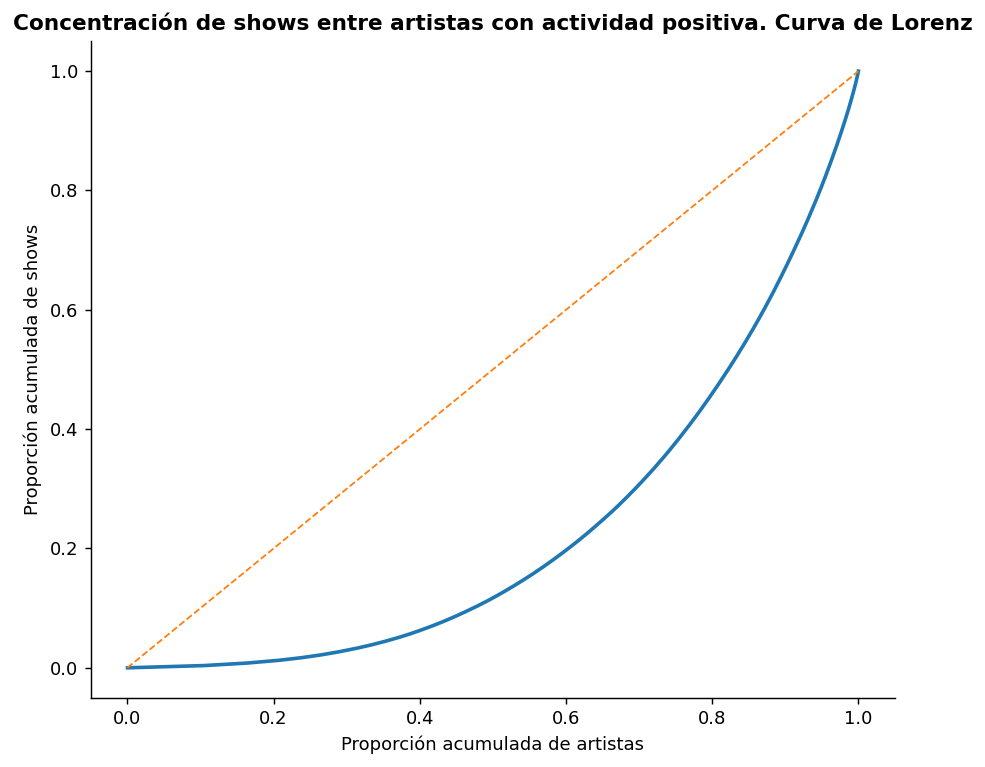

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
#CURVA LORENZ

# Solo positivos
x = np.sort(s_pos.values)

# Participación acumulada de artistas
share_artistas = np.arange(1, len(x) + 1) / len(x)

# Participación acumulada de shows
share_shows = np.cumsum(x) / x.sum()

plt.figure(figsize=(7, 6))
plt.plot(share_artistas, share_shows, linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.title("Concentración de shows entre artistas con actividad positiva. Curva de Lorenz")
plt.xlabel("Proporción acumulada de artistas")
plt.ylabel("Proporción acumulada de shows")
plt.tight_layout()
plt.show()

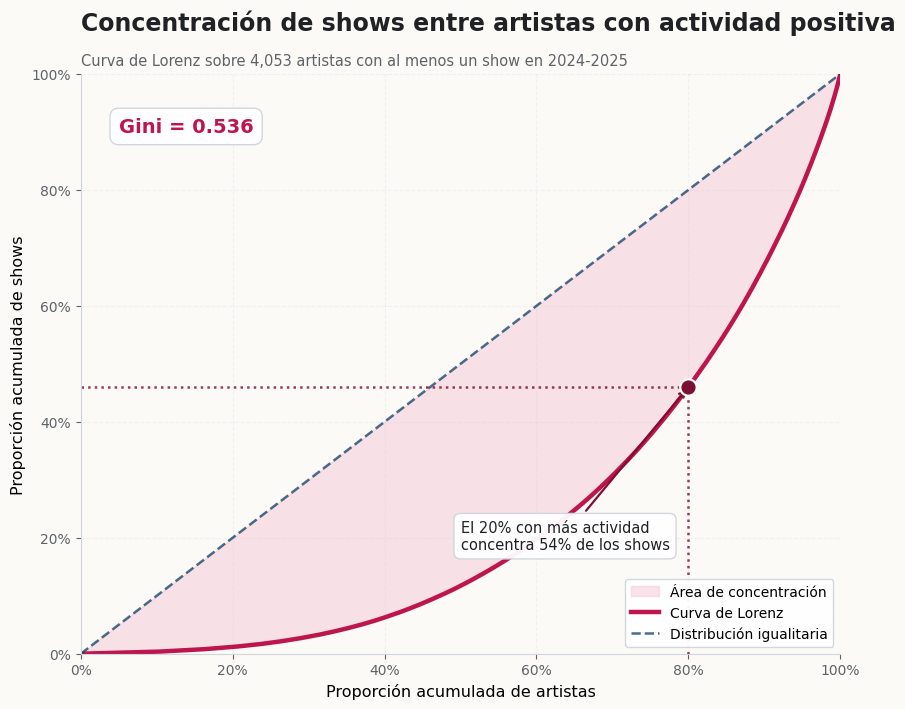

Gini shows positivos: 0.536
Top 20% artistas concentra: 54.0% de los shows
Gráfico guardado en: graficos\curva_lorenz_n_shows_24_25_artistas_positivos.png


In [ ]:
# ============================================================
# Curva de Lorenz de shows entre artistas con actividad positiva
# ============================================================

import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Directorio de guardado
# ------------------------------------------------------------

if "graficos_dir" not in globals():
    graficos_dir = pathlib.Path("graficos")
    graficos_dir.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Preparación de datos
# ------------------------------------------------------------

target_shows = "n_shows_24_25"

if "s_pos" not in globals():
    s_pos = (
        df_tp[target_shows]
        .dropna()
        .loc[df_tp[target_shows] > 0]
    )

shows_positivos_ordenados = np.sort(
    pd.Series(s_pos).dropna().astype(float).values
)

assert len(shows_positivos_ordenados) > 0, (
    "No hay artistas con actividad positiva para calcular la curva de Lorenz."
)

total_artistas_positivos = len(shows_positivos_ordenados)
total_shows_positivos = shows_positivos_ordenados.sum()

participacion_acumulada_artistas = np.insert(
    np.arange(1, total_artistas_positivos + 1) / total_artistas_positivos,
    0,
    0
)

participacion_acumulada_shows = np.insert(
    np.cumsum(shows_positivos_ordenados) / total_shows_positivos,
    0,
    0
)

area_bajo_lorenz = np.trapezoid(
    participacion_acumulada_shows,
    participacion_acumulada_artistas
)

gini_shows_positivos = 1 - 2 * area_bajo_lorenz

punto_80_artistas = 0.80

participacion_shows_bottom_80 = np.interp(
    punto_80_artistas,
    participacion_acumulada_artistas,
    participacion_acumulada_shows
)

participacion_shows_top_20 = 1 - participacion_shows_bottom_80

# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

color_lorenz = "#BD164F"
color_igualdad = "#0C3E63"
color_area = "#F3C1D2"
color_punto = "#7D0E34"
color_texto = "#202124"
color_secundario = "#5F6368"
color_grilla = "#D0D5DD"
color_fondo = "#FBFAF7"

fig, ax = plt.subplots(figsize=(8.8, 7.2))
fig.patch.set_facecolor(color_fondo)
ax.set_facecolor(color_fondo)

ax.fill_between(
    participacion_acumulada_artistas,
    participacion_acumulada_shows,
    participacion_acumulada_artistas,
    color=color_area,
    alpha=0.45,
    label="Área de concentración"
)

ax.plot(
    participacion_acumulada_artistas,
    participacion_acumulada_shows,
    color=color_lorenz,
    linewidth=3.2,
    label="Curva de Lorenz"
)

ax.plot(
    [0, 1],
    [0, 1],
    color=color_igualdad,
    linestyle="--",
    linewidth=1.8,
    alpha=0.75,
    label="Distribución igualitaria"
)

ax.scatter(
    [punto_80_artistas],
    [participacion_shows_bottom_80],
    s=140,
    color=color_punto,
    edgecolor="white",
    linewidth=1.6,
    zorder=5
)

ax.axvline(
    punto_80_artistas,
    ymin=0,
    ymax=participacion_shows_bottom_80,
    color=color_punto,
    linestyle=":",
    linewidth=1.8,
    alpha=0.8
)

ax.axhline(
    participacion_shows_bottom_80,
    xmin=0,
    xmax=punto_80_artistas,
    color=color_punto,
    linestyle=":",
    linewidth=1.8,
    alpha=0.8
)

texto_anotacion = (
    f"El 20% con más actividad\n"
    f"concentra {participacion_shows_top_20:.0%} de los shows"
)

ax.annotate(
    texto_anotacion,
    xy=(punto_80_artistas, participacion_shows_bottom_80),
    xytext=(0.50, 0.18),
    textcoords="axes fraction",
    arrowprops=dict(
        arrowstyle="->",
        color=color_punto,
        lw=1.6
    ),
    fontsize=10.5,
    color=color_texto,
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor="white",
        edgecolor=color_grilla,
        alpha=0.95
    )
)

ax.text(
    0.05,
    0.90,
    f"Gini = {gini_shows_positivos:.3f}",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    color=color_lorenz,
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor="white",
        edgecolor=color_grilla,
        alpha=0.96
    )
)

titulo_grafico = "Concentración de shows entre artistas con actividad positiva"

subtitulo_grafico = (
    f"Curva de Lorenz sobre {total_artistas_positivos:,} artistas con al menos un show "
    f"en 2024-2025"
)

ax.set_title(
    titulo_grafico,
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=32,
    color=color_texto
)

ax.text(
    0,
    1.015,
    subtitulo_grafico,
    transform=ax.transAxes,
    fontsize=10.5,
    color=color_secundario
)

ax.set_xlabel("Proporción acumulada de artistas", fontsize=11.5)
ax.set_ylabel("Proporción acumulada de shows", fontsize=11.5)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.set_xticks(np.linspace(0, 1, 6))
ax.set_yticks(np.linspace(0, 1, 6))

ax.set_xticklabels([f"{x:.0%}" for x in np.linspace(0, 1, 6)])
ax.set_yticklabels([f"{y:.0%}" for y in np.linspace(0, 1, 6)])

ax.grid(axis="both", linestyle="--", alpha=0.25, color=color_grilla)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(color_grilla)
ax.spines["bottom"].set_color(color_grilla)

ax.tick_params(axis="x", colors=color_secundario)
ax.tick_params(axis="y", colors=color_secundario)

ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor=color_grilla,
    framealpha=0.95,
    loc="lower right",
    fontsize=10
)

plt.tight_layout()

ruta_lorenz_shows = (
    graficos_dir /
    f"curva_lorenz_{target_shows}_artistas_positivos.png"
)

plt.savefig(
    ruta_lorenz_shows,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print(f"Gini shows positivos: {gini_shows_positivos:.3f}")
print(f"Top 20% artistas concentra: {participacion_shows_top_20:.1%} de los shows")
print(f"Gráfico guardado en: {ruta_lorenz_shows}")

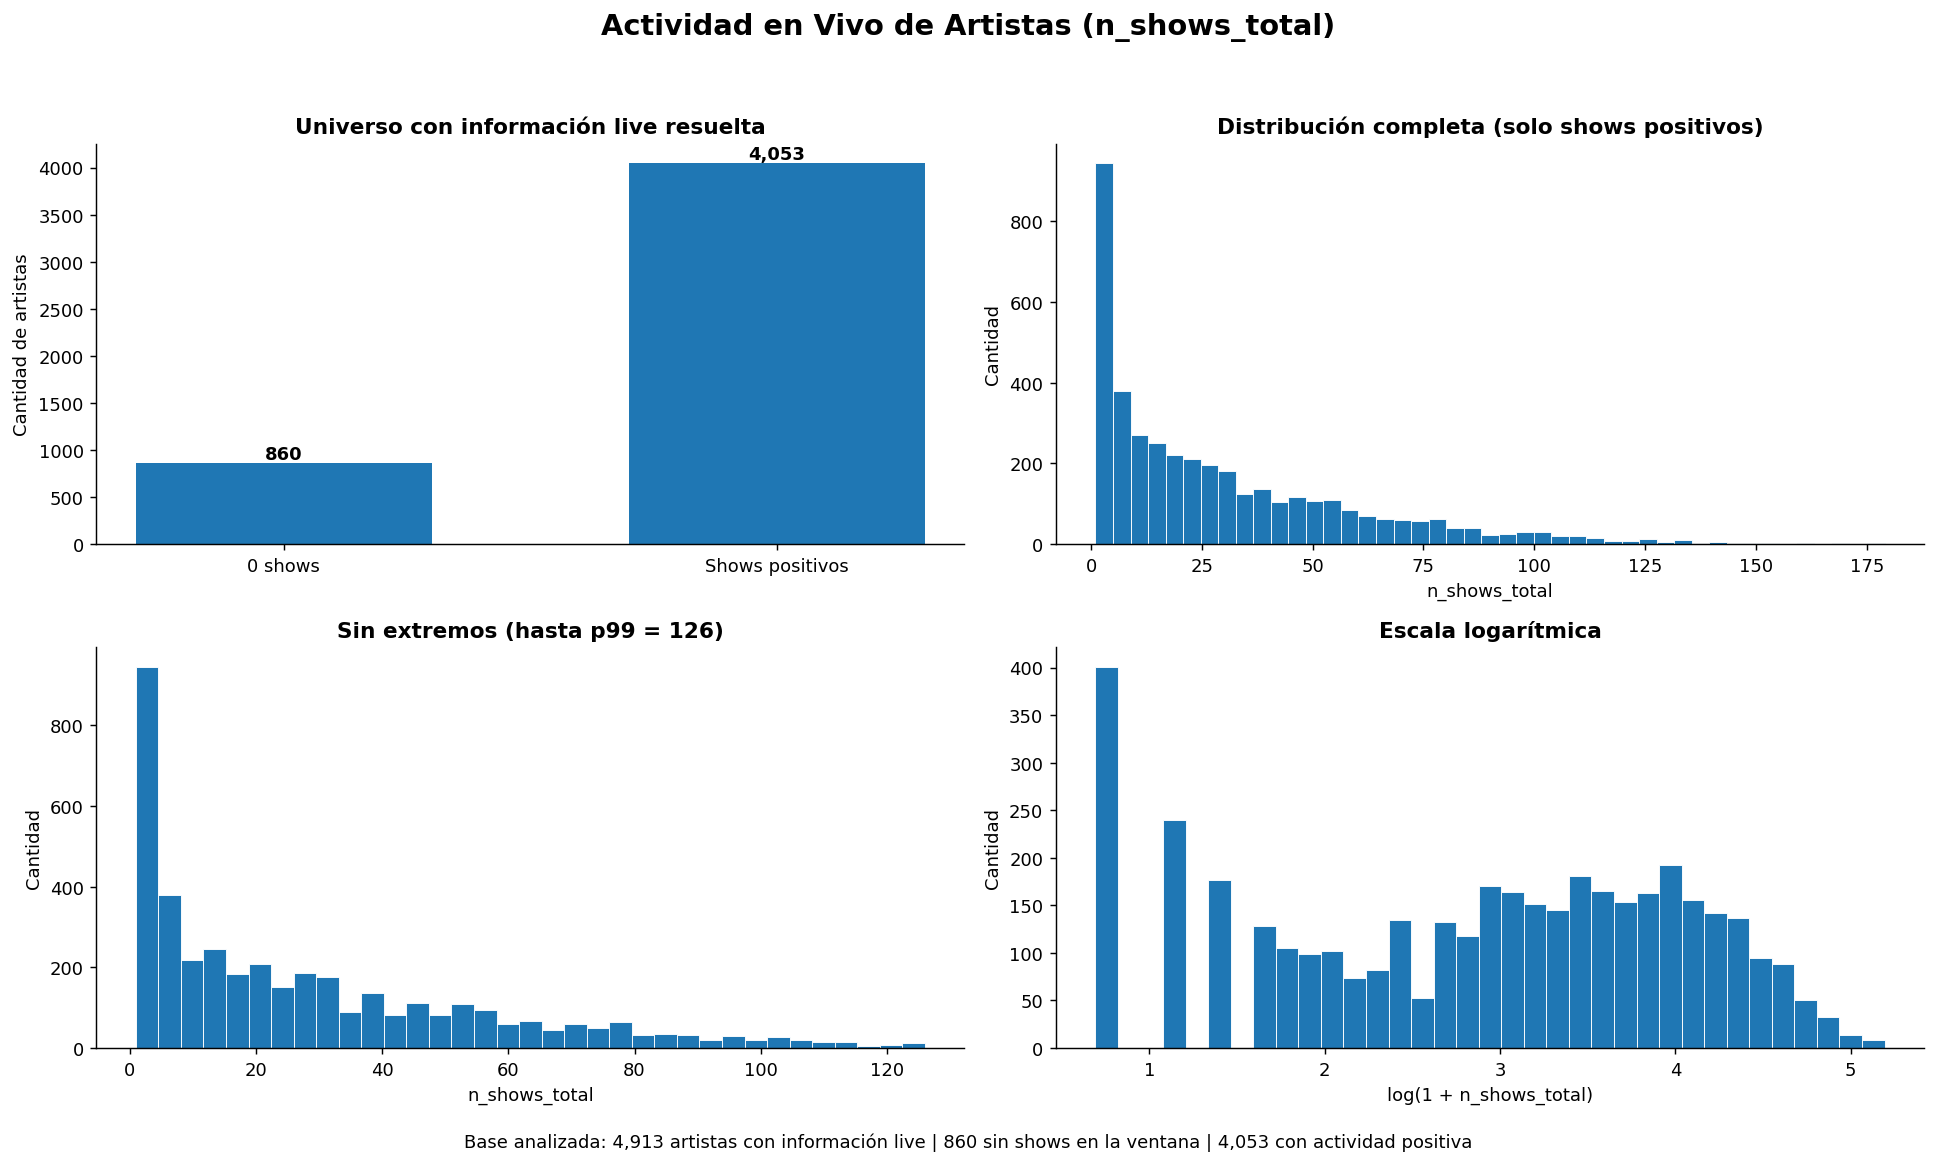

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ============================================================
# ESTILO GENERAL
# ============================================================

plt.style.use("default")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["axes.titlesize"] = 12

# ============================================================
# DATA
# ============================================================

s = df_live["n_shows_24_25"].dropna()
s_pos = s[s > 0]

n_total = len(s)
n_zero = (s == 0).sum()
n_pos = (s > 0).sum()

p99 = s_pos.quantile(0.99)
s_trim = s_pos[s_pos <= p99]
s_log = np.log1p(s_pos)

# ============================================================
# FIGURA
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle(
    "Actividad en Vivo de Artistas (n_shows_total)",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

# ------------------------------------------------------------
# PANEL 1
# ------------------------------------------------------------

vals = [n_zero, n_pos]
labels = ["0 shows", "Shows positivos"]

bars = axes[0, 0].bar(
    labels,
    vals,
    width=0.6
)

axes[0, 0].set_title("Universo con información live resuelta")
axes[0, 0].set_ylabel("Cantidad de artistas")

for bar in bars:
    h = bar.get_height()
    axes[0, 0].text(
        bar.get_x() + bar.get_width()/2,
        h,
        f"{int(h):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# ------------------------------------------------------------
# PANEL 2
# ------------------------------------------------------------

axes[0, 1].hist(
    s_pos,
    bins=45,
    edgecolor="white",
    linewidth=0.5
)

axes[0, 1].set_title("Distribución completa (solo shows positivos)")
axes[0, 1].set_xlabel("n_shows_total")
axes[0, 1].set_ylabel("Cantidad")

axes[0, 1].xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{int(x)}")
)

# ------------------------------------------------------------
# PANEL 3
# ------------------------------------------------------------

axes[1, 0].hist(
    s_trim,
    bins=35,
    edgecolor="white",
    linewidth=0.5
)

axes[1, 0].set_title(f"Sin extremos (hasta p99 = {p99:.0f})")
axes[1, 0].set_xlabel("n_shows_total")
axes[1, 0].set_ylabel("Cantidad")

axes[1, 0].xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{int(x)}")
)

# ------------------------------------------------------------
# PANEL 4
# ------------------------------------------------------------

axes[1, 1].hist(
    s_log,
    bins=35,
    edgecolor="white",
    linewidth=0.5
)

axes[1, 1].set_title("Escala logarítmica")
axes[1, 1].set_xlabel("log(1 + n_shows_total)")
axes[1, 1].set_ylabel("Cantidad")

# ------------------------------------------------------------
# FOOTNOTE
# ------------------------------------------------------------

fig.text(
    0.5,
    0.01,
    f"Base analizada: {n_total:,} artistas con información live | "
    f"{n_zero:,} sin shows en la ventana | {n_pos:,} con actividad positiva",
    ha="center",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
df_live.shape

(4913, 53)

In [ ]:
# ============================================================
# Distribución básica de n_shows_total
# dentro del subset df_live
# Se asume que df_live es un dataframe filtrado
# ============================================================

import pandas as pd
import numpy as np

# Serie base
s = df_live["n_shows_24_25"].dropna()

print("===================================")
print("DESCRIPCIÓN GENERAL")
print("===================================")

print(s.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

print("\n===================================")
print("TRAMOS")
print("===================================")

print(f"valor 0:           {(s == 0).sum():,}  ({(s == 0).mean():.1%})")
print(f"valor 1-12:         {s.between(1, 12).sum():,}  ({s.between(1, 12).mean():.1%})")
print(f"valor 13-48:        {s.between(13, 48).sum():,}  ({s.between(13, 48).mean():.1%})")
print(f"valor > 48:        {(s > 48).sum():,}  ({(s > 48).mean():.1%})")

print("\n===================================")
print("EXTREMOS")
print("===================================")

print(f"máximo:            {s.max():.0f}")
print(f"media:             {s.mean():.2f}")
print(f"mediana:           {s.median():.2f}")
print(f"desvío estándar:   {s.std():.2f}")

DESCRIPCIÓN GENERAL
count       4913.0
mean     24.299003
std      29.668945
min            0.0
25%            1.0
50%           13.0
75%           38.0
90%           68.0
95%           86.0
99%          124.0
max          179.0
Name: n_shows_24_25, dtype: Float64

TRAMOS
valor 0:           860  (17.5%)
valor 1-12:         1,596  (32.5%)
valor 13-48:        1,542  (31.4%)
valor > 48:        915  (18.6%)

EXTREMOS
máximo:            179
media:             24.30
mediana:           13.00
desvío estándar:   29.67


# SAVE 4913

In [ ]:
nombre_archivo = "dataset_4913_53.csv" 

df_live.to_csv(nombre_archivo, index=False, encoding='utf-8-sig')

print(f" Archivo '{nombre_archivo}' guardado con éxito en carpeta de trabajo.")

 Archivo 'dataset_4913_53.csv' guardado con éxito en carpeta de trabajo.
